In [2]:
import os
import re
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams
import matplotlib.patches as patches
from scipy.optimize import curve_fit, minimize
import os
import glob



#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

In [3]:
RUNS = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]
BASE_DIR = "/scratch/elena/9Li/results"


def get_beam_momentum(run_id):
    if run_id in [1846, 1848]:
        return "-340 MeV/c"
    else:
        return "-260 MeV/c"


# Diccionario para almacenar los resúmenes de ambas muestras
summaries = {
    "SIGNAL": {"before": [], "after": []},
    "BACKGROUND (BKG)": {"before": [], "after": []},
}

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    momentum = get_beam_momentum(run)

    # --------------------------------------------------------------------------
    # PROCESADO DE CONFIGURACIONES (SIGNAL Y BKG)
    # --------------------------------------------------------------------------
    for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
        is_bkg = mode == "BACKGROUND (BKG)"

        # Definir los patrones de archivos según el modo
        suffix = "_BKG" if is_bkg else ""
        refined_pattern = os.path.join(
            run_folder, f"Refine_Li9_clusters_chunk*{suffix}.pkl"
        )
        final_fv_file = os.path.join(
            run_folder, f"Final_FV_Li9_clusters_run{run}{suffix}.pkl"
        )

        # 1. Conteo BEFORE FV (Refine chunks)
        refined_files = glob.glob(refined_pattern)
        total_before = 0
        for f in refined_files:
            try:
                df_chunk = pd.read_pickle(f)
                total_before += len(df_chunk)
            except Exception:
                pass  # Manejo seguro de archivos vacíos o corruptos

        summaries[mode]["before"].append(
            {
                "Run": f"Run {run}",
                "Beam Momentum": momentum,
                "Clusters (Before FV)": total_before,
            }
        )

        # 2. Conteo AFTER FV (Final file)
        total_after = 0
        if os.path.exists(final_fv_file):
            try:
                df_final = pd.read_pickle(final_fv_file)
                total_after = len(df_final)
            except Exception:
                pass

        summaries[mode]["after"].append(
            {
                "Run": f"Run {run}",
                "Beam Momentum": momentum,
                "Clusters (Within FV)": total_after,
            }
        )

# ------------------------------------------------------------------------------
# REPRESENTACIÓN DE TABLAS POR PANTALLA
# ------------------------------------------------------------------------------
for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
    df_before = pd.DataFrame(summaries[mode]["before"])
    df_after = pd.DataFrame(summaries[mode]["after"])

    print("\n" + "#" * 65)
    print(f" MUESTRA: {mode}")
    print("#" * 65)

    print("=" * 60)
    print("TABLE 1: CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT (REFINE)")
    print("=" * 60)
    print(df_before.to_string(index=False))

    print("\n" + "=" * 60)
    print("TABLE 2: FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME (FINAL)")
    print("=" * 60)
    print(df_after.to_string(index=False))
    print("\n")


#################################################################
 MUESTRA: SIGNAL
#################################################################
TABLE 1: CLUSTER CANDIDATES BEFORE FIDUCIAL VOLUME CUT (REFINE)
     Run Beam Momentum  Clusters (Before FV)
Run 1846    -340 MeV/c                 80569
Run 1848    -340 MeV/c                 75392
Run 1928    -260 MeV/c                111628
Run 1930    -260 MeV/c                136574
Run 1932    -260 MeV/c                148065
Run 1934    -260 MeV/c                 95110
Run 1935    -260 MeV/c                 97552
Run 1936    -260 MeV/c                 79024
Run 1937    -260 MeV/c                111284
Run 1938    -260 MeV/c                 61164
Run 1939    -260 MeV/c                103921
Run 1941    -260 MeV/c                135689

TABLE 2: FINAL CLUSTER CANDIDATES WITHIN THE FIDUCIAL VOLUME (FINAL)
     Run Beam Momentum  Clusters (Within FV)
Run 1846    -340 MeV/c                     0
Run 1848    -340 MeV/c                   

In [4]:
# ============================================================
# Z projection of final Li9 candidates
# (comparison of -340 MeV/c and -260 MeV/c)
# ============================================================

import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = "/scratch/elena/9Li/results"

RUNS_340 = [1846, 1848]
RUNS_260 = [1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def load_final_vertices(run_list):

    dfs = []

    for run in run_list:

        filename = os.path.join(
            BASE_DIR,
            f"run{run}",
            "processed",
            f"Final_FV_Li9_clusters_run{run}.pkl"
        )

        if os.path.exists(filename):

            df = pd.read_pickle(filename)

            df["run"] = run

            dfs.append(df)

    if len(dfs) == 0:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)


# ------------------------------------------------------------
# Load data
# ------------------------------------------------------------

df340 = load_final_vertices(RUNS_340)
df260 = load_final_vertices(RUNS_260)

print(f"-340 MeV/c : {len(df340)} candidates")
print(f"-260 MeV/c : {len(df260)} candidates")

# ------------------------------------------------------------
# Number of spills
# ------------------------------------------------------------

nSpills340 = df340["spill_id"].nunique()
nSpills260 = df260["spill_id"].nunique()

print("Spills:")
print("-340:", nSpills340)
print("-260:", nSpills260)

# ------------------------------------------------------------
# Histogram
# ------------------------------------------------------------

bins = np.arange(-140, 15, 8)

weights340 = np.ones(len(df340))/nSpills340
weights260 = np.ones(len(df260))/nSpills260

plt.figure(figsize=(12,7))

plt.hist(
    df340["v_z_fine"],
    bins=bins,
    weights=weights340,
    histtype="step",
    linewidth=2.5,
    color="royalblue",
    label=f"Beam p = -340 MeV/c (c.c. ={len(df340)})"
)

plt.hist(
    df260["v_z_fine"],
    bins=bins,
    weights=weights260,
    histtype="step",
    linewidth=2.5,
    linestyle="--",
    color="crimson",
    label=f"Beam p = -260 MeV/c (c.c. = {len(df260)})"
)

plt.xlabel("z [cm]")
plt.ylabel("cluster candidates (c.c.) / spill")

plt.title("z-projection of $^{9}$Li final candidates")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.show()

-340 MeV/c : 0 candidates
-260 MeV/c : 0 candidates


KeyError: 'spill_id'

In [5]:
RUN_TEST = 1848

BASE_DIR = "/scratch/elena/9Li/results"
run_folder = f"{BASE_DIR}/run{RUN_TEST}/processed"

# Definimos los tres archivos/patrones objetivos exclusivamente para SIGNAL
stages_to_inspect = {
    "STAGE 1 (Original Chunks)": os.path.join(
        run_folder, "Li9_clusters_chunk*.pkl"
    ),
    "STAGE 2 (Refined Chunks)": os.path.join(
        run_folder, "Refine_Li9_clusters_chunk*.pkl"
    ),
    "STAGE 3 (Final FV File)": os.path.join(
        run_folder, f"Final_FV_Li9_clusters_run{RUN_TEST}.pkl"
    ),
}

print("=" * 65)
print(f"INSPECTION OF SIGNAL PIPELINE STAGES FOR RUN {RUN_TEST}")
print("=" * 65)


def inspect_stage_file(stage_name, pattern_or_file):
    # Si contiene un asterisco es un patrón de chunks, si no, es el archivo final único
    files = (
        sorted(glob.glob(pattern_or_file))
        if "*" in pattern_or_file
        else [pattern_or_file]
    )

    if files and os.path.exists(files[0]):
        target_file = files[0]
        print(f"\n[{stage_name}] Found: {os.path.basename(target_file)}")
        try:
            df = pd.read_pickle(target_file)
            print("Available columns:")
            print(sorted(list(df.columns)))
        except Exception as e:
            print(f"Error reading file: {e}")
    else:
        print(
            f"\n[{stage_name}] Warning: No files found to inspect for pattern '{os.path.basename(pattern_or_file)}'."
        )


# Ejecutamos la inspección de forma secuencial y limpia
for stage, path in stages_to_inspect.items():
    inspect_stage_file(stage, path)

print("\n" + "=" * 65)

INSPECTION OF SIGNAL PIPELINE STAGES FOR RUN 1848

[STAGE 1 (Original Chunks)] Found: Li9_clusters_chunk_0.pkl
Available columns:
['hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'nCLusters_in_spill', 'nHits', 'spill_id', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns']

[STAGE 2 (Refined Chunks)] Found: Refine_Li9_clusters_chunk_0.pkl
Available columns:
['chi2', 'chi2_ndof', 'fit_success', 'hit_charges', 'hit_position_ids', 'hit_slot_ids', 'hit_times_ns', 'hits_after', 'nCLusters_in_spill', 'nHits', 'n_hits_used', 'ndof', 'spill_id', 't_rms_fine', 't_rms_ns', 't_window_start_ns', 't_window_start_rel_ns', 'time_rms', 'v_x_fine', 'v_y_fine', 'v_z_fine', 'vertex_x', 'vertex_y', 'vertex_z']

[STAGE 3 (Final FV File)] Warning: No files found to inspect for pattern 'Final_FV_Li9_clusters_run1848.pkl'.



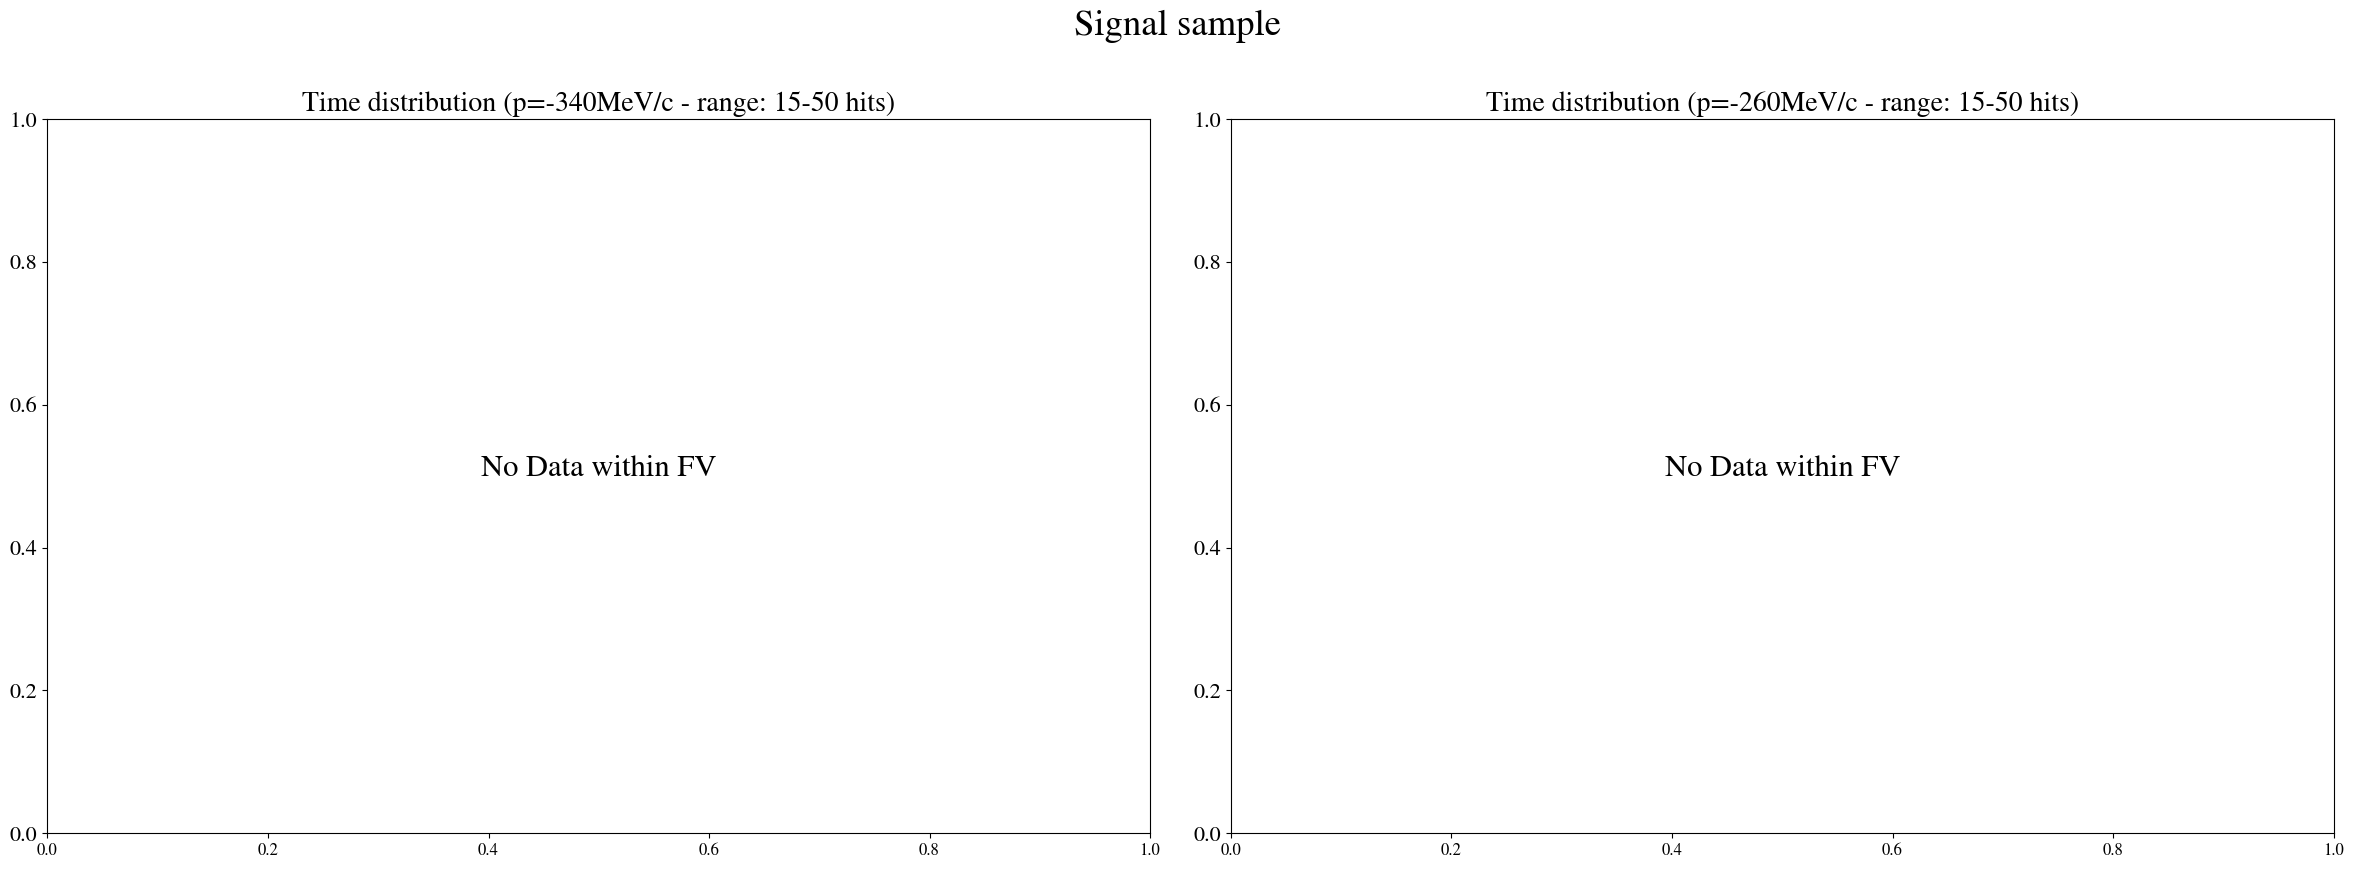

In [6]:
momentum_map = {run: get_beam_momentum(run) for run in RUNS}

dfs_340 = []
dfs_260 = []

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    
    if os.path.exists(final_fv_file):
        try:
            df = pd.read_pickle(final_fv_file)
            if not df.empty:
                df['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340.append(df)
                else:
                    dfs_260.append(df)
        except Exception as e:
            print(f"Error loading {final_fv_file}: {e}")

df_340_combined = pd.concat(dfs_340, ignore_index=True) if dfs_340 else pd.DataFrame()
df_260_combined = pd.concat(dfs_260, ignore_index=True) if dfs_260 else pd.DataFrame()


# PLOTS

rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        #"const_line": 45.98  # Constant line value for 340 MeV/c
    },
    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        #"const_line": 45.98  # Adjust this value if the 260 MeV/c background baseline differs
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    # UNIT CONVERSION CRITICAL FIX: Convert 't_window_start_rel_ns' from ns to ms
    time_in_ms = df_plot[time_column] / 1e6

    # Apply the exact histogram logic with the 20 ms offset shift
    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))

    # Draw step histogram profile
    ax.stairs(counts,bin_edges,color="royalblue",linewidth=1.5,
        label=(
            f"SIGNAL DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )

    #error data points
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="darkblue", markersize=4, capsize=0, elinewidth=1, ls="none")

    # Horizontal baseline restriction strictly bounded between 20 ms and 500 ms
    #ax.hlines(y=config["const_line"], xmin=20, xmax=500, color="red", linewidth=2.5, label=f"C = {config['const_line']}")

   
    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    

    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, 350)
    
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("Signal sample")
plt.tight_layout()
plt.show()

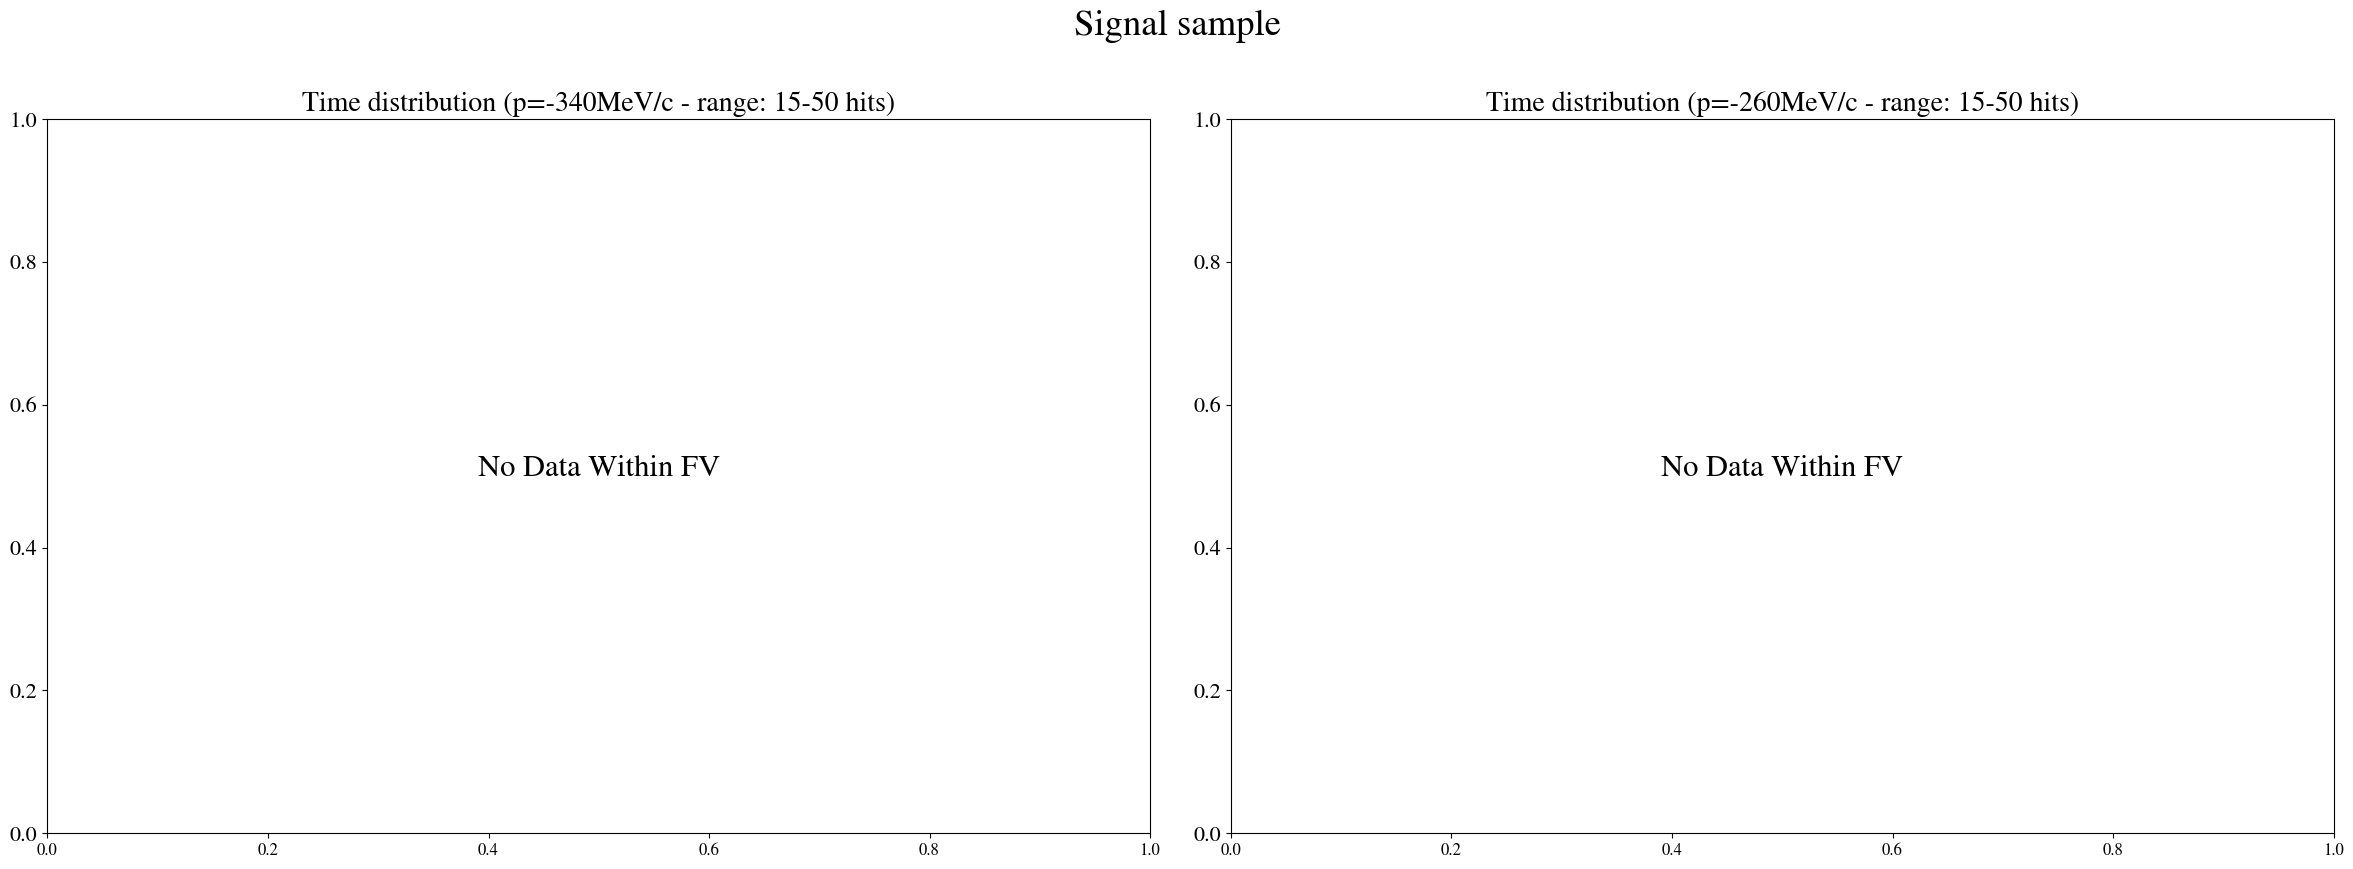

In [7]:
#PLOT ylim fixed!

rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df": df_340_combined,
        "ax": axs[0],
        "title": "Time distribution (p=-340MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_340),
        "y_max": 550  #fixed lim  
    },

    {
        "df": df_260_combined,
        "ax": axs[1],
        "title": "Time distribution (p=-260MeV/c - range: 15-50 hits)",
        "num_runs": len(dfs_260),
        "y_max": 1050  #fixed lim
    }
]

for config in plot_configs:
    df_plot = config["df"]
    ax = config["ax"]
    
    if df_plot.empty:
        ax.text(0.5, 0.5, "No Data Within FV", transform=ax.transAxes, ha="center")
        ax.set_title(config["title"])
        continue

    if time_column not in df_plot.columns:
        print(f"Error: Column '{time_column}' not found.")
        continue

    time_in_ms = df_plot[time_column] / 1e6   #unit conversion

    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
    
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    errors = np.sqrt(np.maximum(counts, 1))


    ax.stairs(counts,bin_edges,color="royalblue",linewidth=1.5,
        label=(
            f"SIGNAL DATA\n"
            f"nClusters: {len(df_plot)}\n"
            f"nSpills: {df_plot['spill_id'].nunique() if 'spill_id' in df_plot.columns else 'N/A'}\n"
            f"nRuns: {config['num_runs']}"
        ),
    )
    ax.errorbar(bin_centers, counts, yerr=errors, fmt="o", color="darkblue", markersize=4, capsize=0, elinewidth=1, ls="none")

    ax.set_title(config["title"])
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms")
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0, config["y_max"]) #fixed ylim
    
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("Signal sample")
plt.tight_layout()
plt.show()

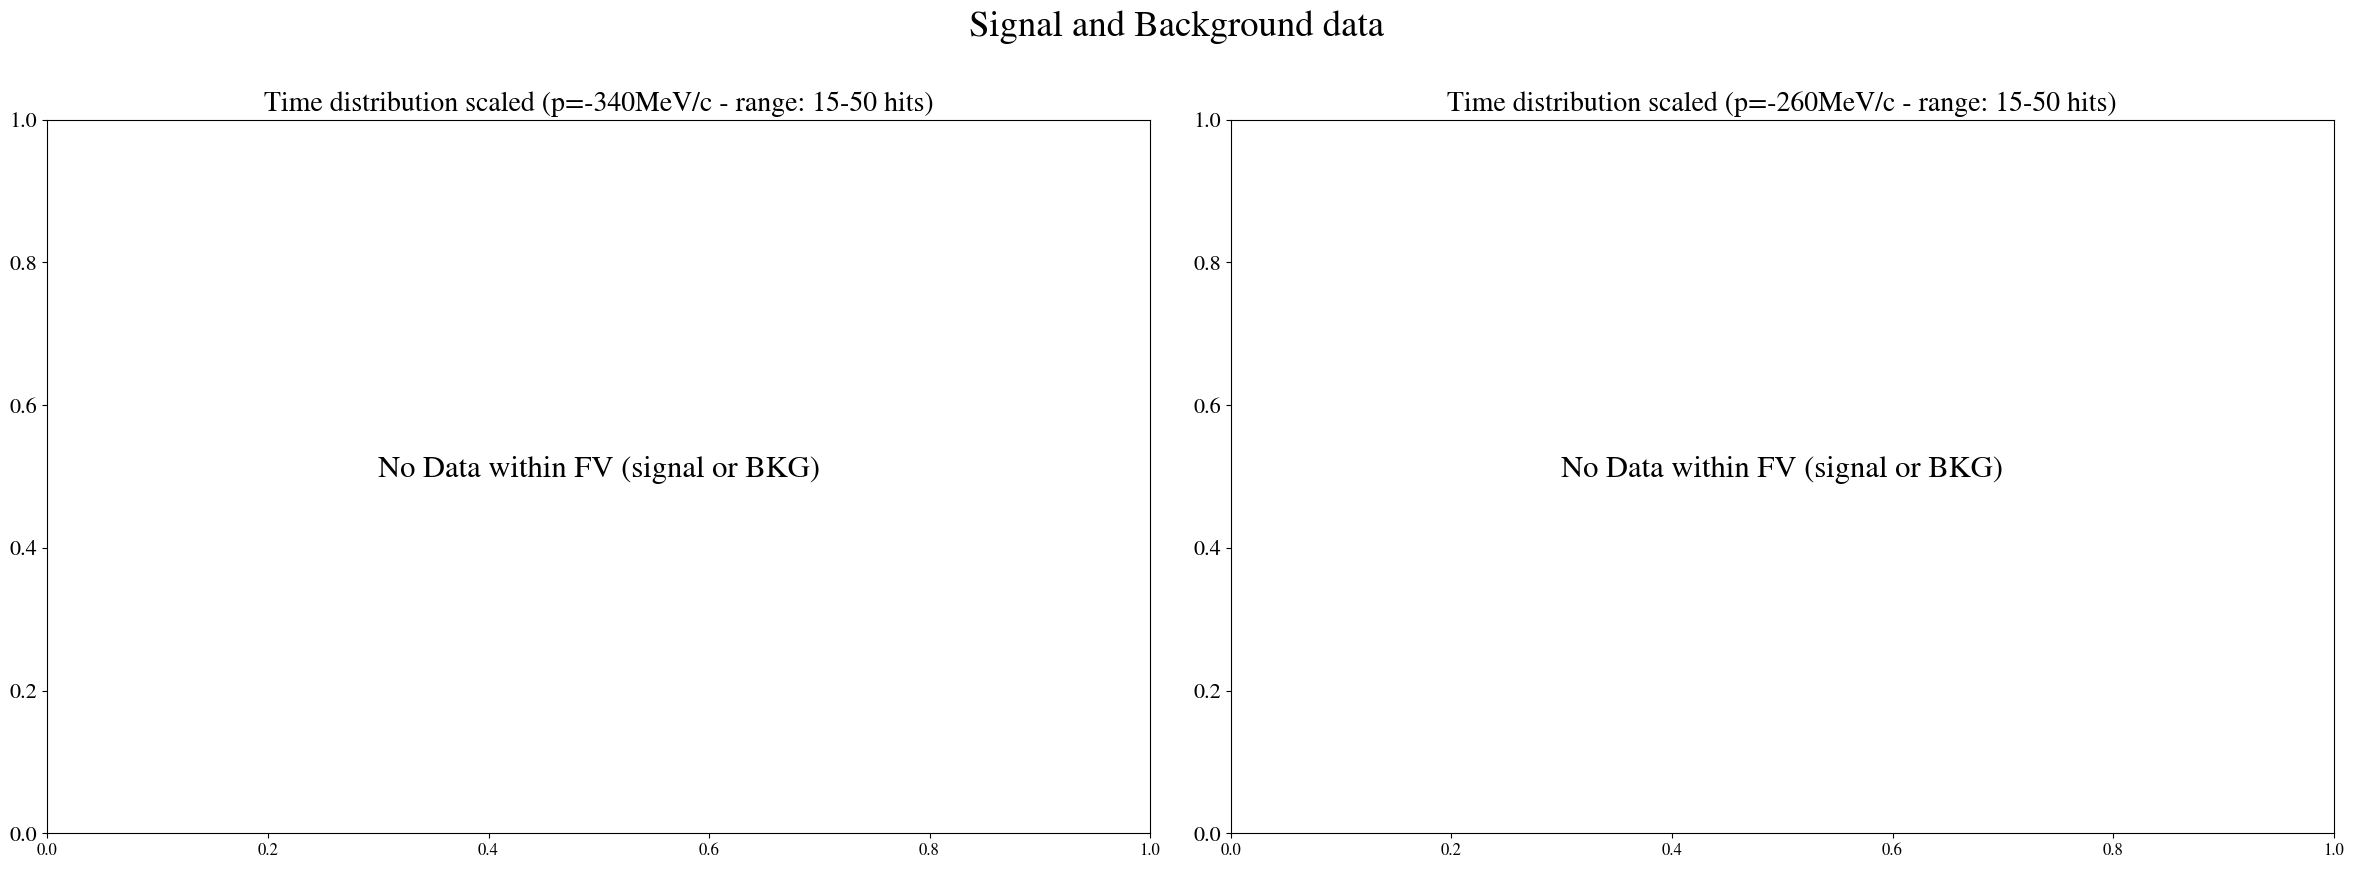

In [8]:
dfs_340_sig = []
dfs_340_bkg = []
dfs_260_sig = []
dfs_260_bkg = []


for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    #load signal data
    if os.path.exists(sig_file):
        try:
            df_sig = pd.read_pickle(sig_file)
            if not df_sig.empty:
                df_sig['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340_sig.append(df_sig)
                else:
                    dfs_260_sig.append(df_sig)
        except Exception as e:
            print(f"Error loading Signal file {sig_file}: {e}")

    #load BKG
    if os.path.exists(bkg_file):
        try:
            df_bkg = pd.read_pickle(bkg_file)
            if not df_bkg.empty:
                df_bkg['origin_run'] = run
                if momentum_map[run] == "-340 MeV/c":
                    dfs_340_bkg.append(df_bkg)
                else:
                    dfs_260_bkg.append(df_bkg)
        except Exception as e:
            print(f"Error loading BKG file {bkg_file}: {e}")

#Safe df concatenation 
df_340_sig_comb = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_340_bkg_comb = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()
df_260_sig_comb = pd.concat(dfs_260_sig, ignore_index=True) if dfs_260_sig else pd.DataFrame()
df_260_bkg_comb = pd.concat(dfs_260_bkg, ignore_index=True) if dfs_260_bkg else pd.DataFrame()

# PLOT
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

# --- NUEVA LÓGICA: CALCULAR EL TOTAL DE SPILLS ÚNICOS POR ENERGÍA ---
def get_unique_spills(df1, df2):
    spills1 = set(df1['spill_id'].unique()) if 'spill_id' in df1.columns else set()
    spills2 = set(df2['spill_id'].unique()) if 'spill_id' in df2.columns else set()
    total_spills = len(spills1.union(spills2))
    return total_spills if total_spills > 0 else 1

spills_340 = get_unique_spills(df_340_sig_comb, df_340_bkg_comb)
spills_260 = get_unique_spills(df_260_sig_comb, df_260_bkg_comb)
# -------------------------------------------------------------------

plot_configs = [
    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "Time distribution scaled (p=-340MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_340_sig),
        "num_runs_bkg": len(dfs_340_bkg),
        "n_spills_global": spills_340  # <-- Pasamos el n_spills global
    },
    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "Time distribution scaled (p=-260MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_260_sig),
        "num_runs_bkg": len(dfs_260_bkg),
        "n_spills_global": spills_260  # <-- Pasamos el n_spills global
    }
]

for config in plot_configs:
    ax = config["ax"]
    ax.set_title(config["title"])
    global_spills = config["n_spills_global"]
    
    # --- SUB-PLOTTER RECIBE EL DIVISOR GLOBAL ---
    def plot_sample(df_plot, sample_label, hist_color, marker_color, num_runs):
        if df_plot.empty or (time_column not in df_plot.columns):
            return False
            
        time_in_ms = df_plot[time_column] / 1e6

        counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- ESCALADO RECTIFICADO (Mismo divisor para Signal y BKG) ---
        counts_scaled = counts / global_spills
        errors_scaled = np.sqrt(np.maximum(counts, 1)) / global_spills

        label_text = (
            f"{sample_label}\n"
            f"nClusters (Total): {len(df_plot)}\n"
            f"nRuns: {num_runs}\n"
            f"clusters/spill (global): {len(df_plot)/global_spills:.2f}"
        )

        ax.stairs(counts_scaled, bin_edges, color=hist_color, linewidth=1.8, label=label_text)
        ax.errorbar(bin_centers, counts_scaled, yerr=errors_scaled, fmt="o", color=marker_color, markersize=4, capsize=0, elinewidth=1, ls="none")
        return True

    # plot BACKGROUND 
    has_bkg = plot_sample(
        config["df_bkg"], "BKG DATA", 
        hist_color="lightgray", marker_color="gray", 
        num_runs=config["num_runs_bkg"]
    )

    # plot SIGNAL
    has_sig = plot_sample(
        config["df_sig"], "SIGNAL DATA", 
        hist_color="royalblue", marker_color="darkblue", 
        num_runs=config["num_runs_sig"]
    )

    if not has_sig and not has_bkg:
        ax.text(0.5, 0.5, "No Data within FV (signal or BKG)", transform=ax.transAxes, ha="center")
        continue

    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms / total spills ({global_spills})") 
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    
    # He quitado el ax.set_ylim(0, 1.60) fijo para que deje autoescalar el eje Y 
    # y no se te corten las curvas ahora que cambiaron los denominadores.
    
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("Signal and Background data")
plt.tight_layout()
plt.show()

-340 MeV/c : 330.0 pion spills
-260 MeV/c : 1196.0 pion spills


/tmp/ipykernel_3131350/749913577.py:146: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper right", frameon=True)


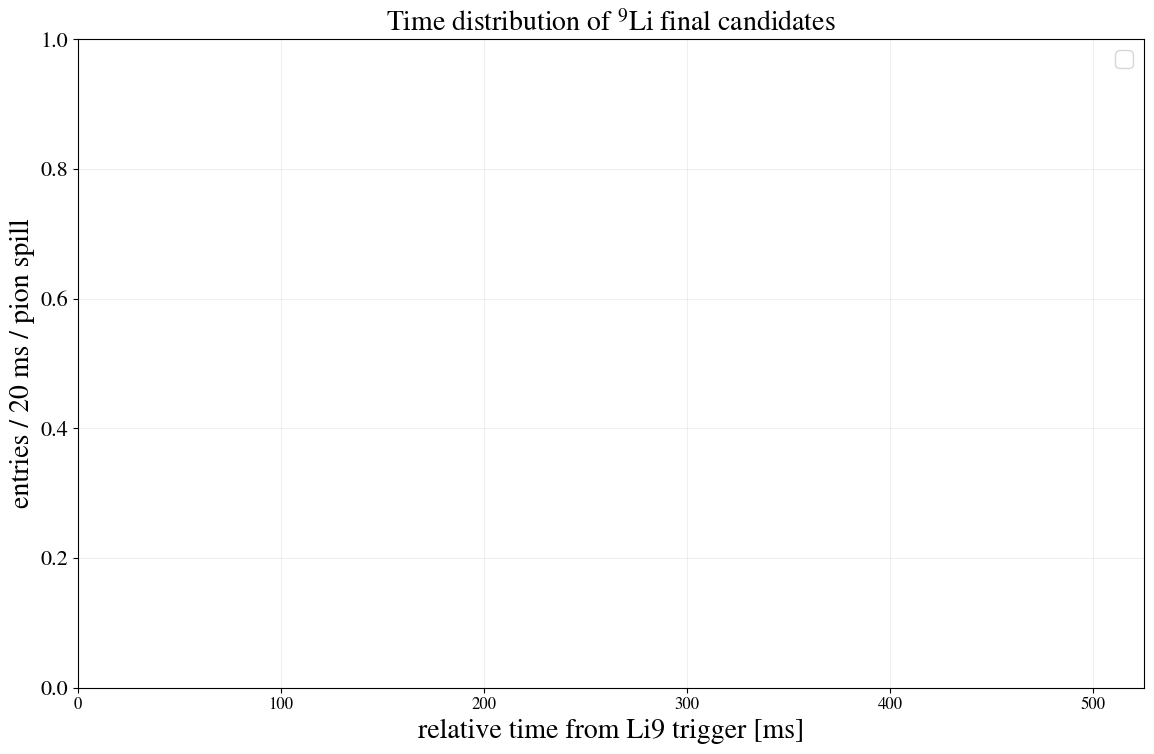

In [9]:
# ==========================================================
# LOAD FINAL SIGNAL CANDIDATES
# ==========================================================

momentum_map = {run: get_beam_momentum(run) for run in RUNS}

dfs_340 = []
dfs_260 = []

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    final_fv_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")

    if os.path.exists(final_fv_file):
        try:
            df = pd.read_pickle(final_fv_file)

            if not df.empty:
                df["origin_run"] = run

                if momentum_map[run] == "-340 MeV/c":
                    dfs_340.append(df)
                else:
                    dfs_260.append(df)

        except Exception as e:
            print(f"Error loading {final_fv_file}: {e}")

df_340_combined = pd.concat(dfs_340, ignore_index=True) if dfs_340 else pd.DataFrame()
df_260_combined = pd.concat(dfs_260, ignore_index=True) if dfs_260 else pd.DataFrame()


# ==========================================================
# TOTAL PION SPILLS (MASTER TABLE)
# ==========================================================

master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"
df_master = pd.read_csv(master_table_path)

spills_340_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -340]["N spills with pions"].sum()
)

spills_260_pion = (
    df_master[df_master["Beam p (MeV/c)"] == -260]["N spills with pions"].sum()
)

print(f"-340 MeV/c : {spills_340_pion} pion spills")
print(f"-260 MeV/c : {spills_260_pion} pion spills")


# ==========================================================
# PLOT
# ==========================================================

rcParams["figure.figsize"] = [12, 8]

fig, ax = plt.subplots()

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"


def draw_sample(df_plot, color, marker_color, linestyle,
                label, num_runs, n_pion_spills):

    if df_plot.empty:
        return

    if time_column not in df_plot.columns:
        print(f"Column '{time_column}' not found.")
        return

    # ns -> ms
    time_in_ms = df_plot[time_column] / 1e6

    counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)

    counts = counts / n_pion_spills
    errors = np.sqrt(np.maximum(counts * n_pion_spills, 1)) / n_pion_spills

    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    ax.stairs(
        counts,
        bin_edges,
        color=color,
        linewidth=2,
        linestyle=linestyle,
        label=(
            f"{label}\n"
            f"nClusters: {len(df_plot)}\n"
            f"n total spills: {n_pion_spills}\n"
            f"nRuns: {num_runs}\n"
            f"clusters/ spill (pion): {len(df_plot)/n_pion_spills:.4f}"
        ),
    )

    ax.errorbar(
        bin_centers,
        counts,
        yerr=errors,
        fmt="o",
        color=marker_color,
        markersize=4,
        capsize=0,
        elinewidth=1,
        ls="none",
    )


# ==========================================================
# DRAW
# ==========================================================

draw_sample(
    df_340_combined,
    color="royalblue",
    marker_color="darkblue",
    linestyle="-",
    label="Beam p = -340 MeV/c",
    num_runs=len(dfs_340),
    n_pion_spills=spills_340_pion,
)

draw_sample(
    df_260_combined,
    color="crimson",
    marker_color="darkred",
    linestyle="--",
    label="Beam p = -260 MeV/c",
    num_runs=len(dfs_260),
    n_pion_spills=spills_260_pion,
)

ax.set_title(r"Time distribution of $^{9}$Li final candidates")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms / pion spill")

ax.grid(True, which="both", linestyle="-", alpha=0.2)

ax.set_xlim(0, 525)
ax.set_yscale("linear")

ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

--> [OK] Total pion spills for -340 MeV/c: 330.0
--> [OK] Total pion spills for -260 MeV/c: 1196.0


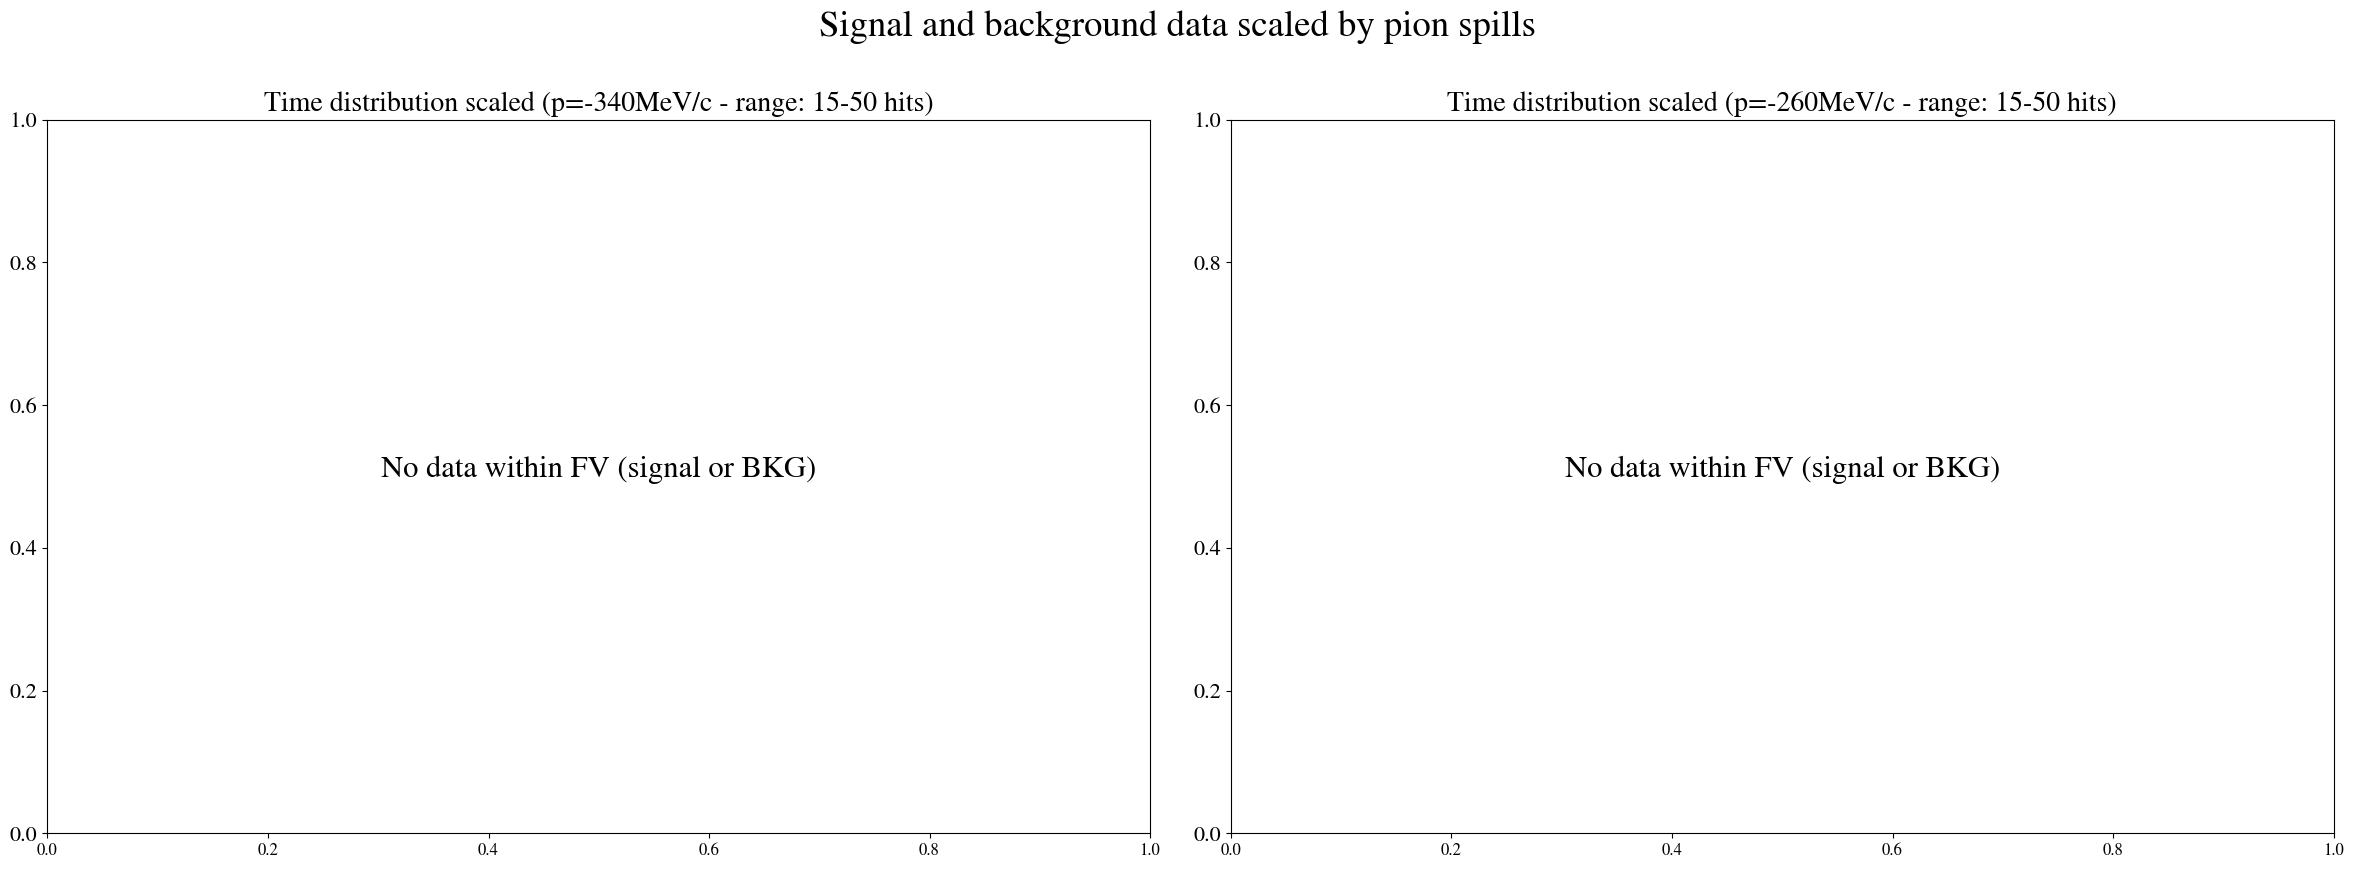

In [10]:
# --- 1. DYNAMIC RETRIEVAL OF PION SPILLS FROM MASTER TABLE ---
master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"
if not os.path.exists(master_table_path):
    raise FileNotFoundError(f"Master table not found at '{master_table_path}'. Please check the path.")

df_master = pd.read_csv(master_table_path)

# Dynamically sum total pion spills from your master table for each beam momentum configuration
spills_340_pion = df_master[df_master["Beam p (MeV/c)"] == -340]["N spills with pions"].sum()
spills_260_pion = df_master[df_master["Beam p (MeV/c)"] == -260]["N spills with pions"].sum()

print(f"--> [OK] Total pion spills for -340 MeV/c: {spills_340_pion}")
print(f"--> [OK] Total pion spills for -260 MeV/c: {spills_260_pion}")

# --- 2. DATA LOADING & FILTERING ---
dfs_340_sig = []
dfs_340_bkg = []
dfs_260_sig = []
dfs_260_bkg = []

for run in RUNS:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    # Load signal data
    if os.path.exists(sig_file):
        try:
            df_sig = pd.read_pickle(sig_file)
            if not df_sig.empty:
                df_sig['origin_run'] = run
                if get_beam_momentum(run) == "-340 MeV/c":
                    dfs_340_sig.append(df_sig)
                else:
                    dfs_260_sig.append(df_sig)
        except Exception as e:
            print(f"Error loading signal file {sig_file}: {e}")

    # Load background data
    if os.path.exists(bkg_file):
        try:
            df_bkg = pd.read_pickle(bkg_file)
            if not df_bkg.empty:
                df_bkg['origin_run'] = run
                if get_beam_momentum(run) == "-340 MeV/c":
                    dfs_340_bkg.append(df_bkg)
                else:
                    dfs_260_bkg.append(df_bkg)
        except Exception as e:
            print(f"Error loading background file {bkg_file}: {e}")

# Safe dataframe concatenation
df_340_sig_comb = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_340_bkg_comb = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()
df_260_sig_comb = pd.concat(dfs_260_sig, ignore_index=True) if dfs_260_sig else pd.DataFrame()
df_260_bkg_comb = pd.concat(dfs_260_bkg, ignore_index=True) if dfs_260_bkg else pd.DataFrame()

# --- 3. PLOTTING CONFIGURATION ---
rcParams['figure.figsize'] = [24, 9]
fig, axs = plt.subplots(1, 2, sharey=False)

bin_width = 20  # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns" 

plot_configs = [
    {
        "df_sig": df_340_sig_comb,
        "df_bkg": df_340_bkg_comb,
        "ax": axs[0],
        "title": "Time distribution scaled (p=-340MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_340_sig),
        "num_runs_bkg": len(dfs_340_bkg),
        "n_spills_pion": spills_340_pion  # <-- Dynamic master table value
    },
    {
        "df_sig": df_260_sig_comb,
        "df_bkg": df_260_bkg_comb,
        "ax": axs[1],
        "title": "Time distribution scaled (p=-260MeV/c - range: 15-50 hits)",
        "num_runs_sig": len(dfs_260_sig),
        "num_runs_bkg": len(dfs_260_bkg),
        "n_spills_pion": spills_260_pion  # <-- Dynamic master table value
    }
]

for config in plot_configs:
    ax = config["ax"]
    ax.set_title(config["title"])
    pion_spills = config["n_spills_pion"]
    
    def plot_sample(df_plot, sample_label, hist_color, marker_color, num_runs):
        if df_plot.empty or (time_column not in df_plot.columns):
            return False
            
        time_in_ms = df_plot[time_column] / 1e6

        counts, bin_edges = np.histogram(time_in_ms + 20, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # --- SCALING APPLIED WITH TOTAL PION SPILLS ---
        counts_scaled = counts / pion_spills
        errors_scaled = np.sqrt(np.maximum(counts, 1)) / pion_spills

        label_text = (
            f"{sample_label}\n"
            f"nClusters (total): {len(df_plot)}\n"
            f"nRuns: {num_runs}\n"
            f"clusters / spill (pion): {len(df_plot)/pion_spills:.4f}"
        )

        ax.stairs(counts_scaled, bin_edges, color=hist_color, linewidth=1.8, label=label_text)
        ax.errorbar(bin_centers, counts_scaled, yerr=errors_scaled, fmt="o", color=marker_color, markersize=4, capsize=0, elinewidth=1, ls="none")
        return True

    # Plot background
    has_bkg = plot_sample(
        config["df_bkg"], "BKG DATA", 
        hist_color="lightgray", marker_color="gray", 
        num_runs=config["num_runs_bkg"]
    )

    # Plot signal
    has_sig = plot_sample(
        config["df_sig"], "SIGNAL DATA", 
        hist_color="royalblue", marker_color="darkblue", 
        num_runs=config["num_runs_sig"]
    )

    if not has_sig and not has_bkg:
        ax.text(0.5, 0.5, "No data within FV (signal or BKG)", transform=ax.transAxes, ha="center")
        continue

    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms / total pion spills ({pion_spills})") 
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    ax.set_yscale("linear")
    ax.set_xlim(0, 525)
    ax.set_ylim(0,1.0)
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("Signal and background data scaled by pion spills")
plt.tight_layout()
plt.show()

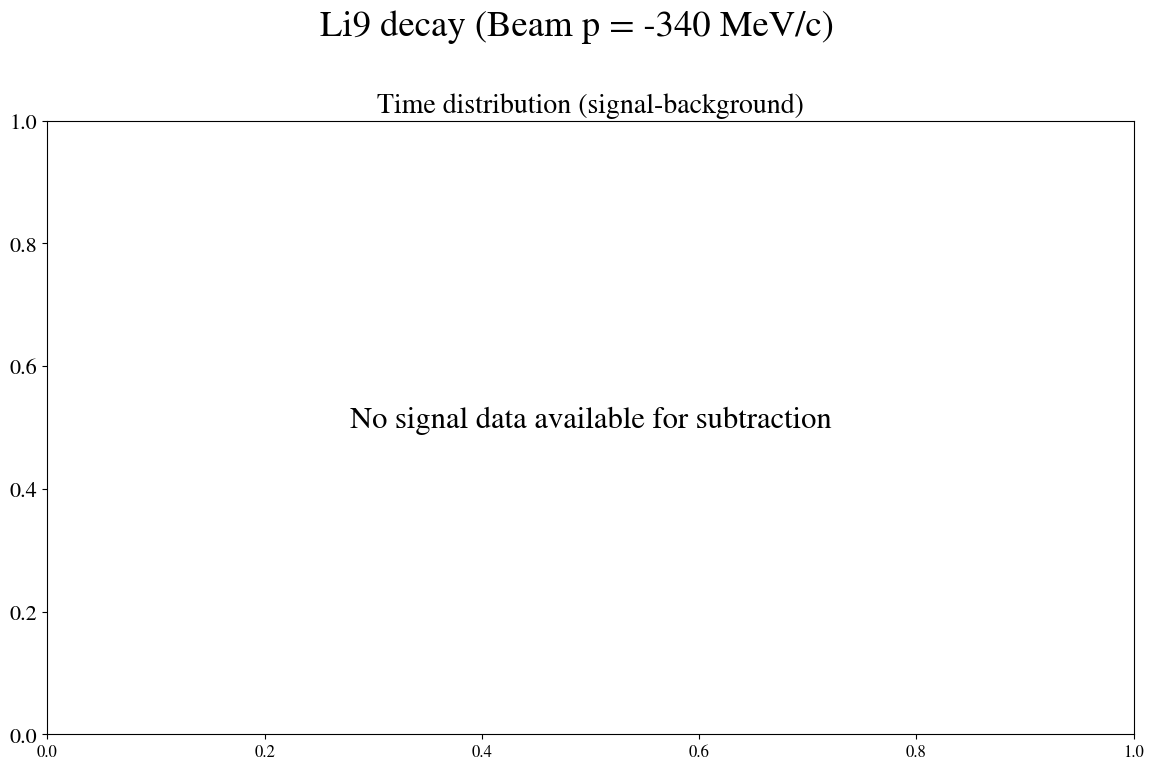

In [11]:
# --- 4. NET SIGNAL EXTRACTION (SIGNAL - BACKGROUND) FOR -340 MeV/c ONLY ---
fig, ax = plt.subplots(figsize=(12,8))

# Configuration only for the -340 MeV/c beam momentum
pion_spills = spills_340_pion
df_sig = df_340_sig_comb
df_bkg = df_340_bkg_comb

ax.set_title("Time distribution (signal-background)")

# Check if we have data to subtract
if df_sig.empty or (time_column not in df_sig.columns):
    ax.text(0.5, 0.5, "No signal data available for subtraction", transform=ax.transAxes, ha="center")
else:
    # Calculate raw histogram counts for signal
    time_sig_ms = df_sig[time_column] / 1e6
    counts_sig, bin_edges = np.histogram(time_sig_ms + 20, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Calculate raw histogram counts for background (or zeros if empty)
    if not df_bkg.empty and (time_column in df_bkg.columns):
        time_bkg_ms = df_bkg[time_column] / 1e6
        counts_bkg, _ = np.histogram(time_bkg_ms + 20, bins=bins)
    else:
        counts_bkg = np.zeros_like(counts_sig)
    
    # --- BIN-BY-BIN SUBTRACTION & SCALING ---
    net_counts_raw = counts_sig - counts_bkg
    net_counts_scaled = net_counts_raw / pion_spills
    
    # Error propagation in quadrature: sqrt(sigma_sig^2 + sigma_bkg^2)
    errors_raw = np.sqrt(counts_sig + counts_bkg)
    errors_raw = np.maximum(errors_raw, 1.0) 
    errors_scaled = errors_raw / pion_spills

    # Calculate integrated net clusters for the legend
    total_net_clusters = net_counts_raw.sum()

    label_text = (
        f"Final SIGNAL (sig-bkg)\n"
        f"clusters (total): {total_net_clusters:.1f}\n"
        f"clusters / spill: {total_net_clusters/pion_spills:.4f}"
    )

    # Plot net distribution
    ax.stairs(net_counts_scaled, bin_edges, color="crimson", linewidth=2.0, label=label_text)
    ax.errorbar(bin_centers, net_counts_scaled, yerr=errors_scaled, fmt="o", color="darkred", 
                markersize=5, capsize=0, elinewidth=1.2, ls="none")
    
    # Formatting
    ax.set_xlabel("relative time from Li9 trigger [ms]")
    ax.set_ylabel(f"entries / {bin_width} ms / total pion spills ({pion_spills})") 
    ax.grid(True, which="both", linestyle="-", alpha=0.2)
    
    # Visual baseline at Y=0 to check statistical fluctuations
    ax.axhline(0, color="black", linestyle="--", alpha=0.5, linewidth=1.0)
    
    ax.set_xlim(0, 525)
    ax.set_ylim(-0.1, 1.0)  
    ax.legend(loc="upper right", frameon=True)

plt.suptitle("Li9 decay (Beam p = -340 MeV/c)")
plt.tight_layout()
plt.show()

In [12]:
print(df_340_sig_comb.columns)

print(df_340_sig_comb["v_z_fine"].describe())
print(df_260_sig_comb["v_z_fine"].describe())

RangeIndex(start=0, stop=0, step=1)


KeyError: 'v_z_fine'

In [13]:
# ============================================================
# Spatial regions vs decay-time distributions
#
# SIGNAL ONLY
#
# One figure per beam momentum
# Time distributions share the same y-axis scale
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

time_bins = np.arange(20, 520, 20)
z_bins = np.arange(-140, 10, 8)

regions = [
    (-140, -110),
    (-110,  -80),
    ( -80,  -50),
    ( -50,    0)
]


def plot_beam(df, beam_label, pion_spills):

    # --------------------------------------------------------
    # Determine common y-axis limit for ALL time distributions
    # --------------------------------------------------------

    ymax = 0

    for zmin, zmax in regions:

        cut = (df["v_z_fine"] >= zmin) & (df["v_z_fine"] < zmax)

        t = df.loc[cut, "t_window_start_rel_ns"] / 1e6

        counts, _ = np.histogram(
            t + 20,
            bins=time_bins
        )

        counts_scaled = counts / pion_spills

        if len(counts_scaled):
            ymax = max(ymax, counts_scaled.max())

    ymax *= 1.15   # 15% margin


    # --------------------------------------------------------
    # Figure
    # --------------------------------------------------------

    fig, axs = plt.subplots(
        len(regions),
        2,
        figsize=(15, 15),
        gridspec_kw={"width_ratios":[1.1,1]}
    )


    # --------------------------------------------------------
    # Loop over spatial regions
    # --------------------------------------------------------

    for i, (zmin, zmax) in enumerate(regions):

        cut = (df["v_z_fine"] >= zmin) & (df["v_z_fine"] < zmax)

        dfr = df[cut]

        ###################################################
        # LEFT : z projection
        ###################################################

        ax = axs[i,0]

        weights = np.ones(len(df)) / df["spill_id"].nunique()

        ax.hist(
            df["v_z_fine"],
            bins=z_bins,
            weights=weights,
            histtype="step",
            color="royalblue",
            linewidth=2
        )

        ax.axvspan(
            zmin,
            zmax,
            color="orange",
            alpha=0.35,
            label=f"{zmin} < z < {zmax}"
        )

        ax.set_ylabel("Candidates / spill")

        if i == len(regions)-1:
            ax.set_xlabel("vertex z [cm]")

        ax.grid(alpha=0.3)

        ax.legend(loc="upper left")


        ###################################################
        # RIGHT : decay time
        ###################################################

        ax = axs[i,1]

        t = dfr["t_window_start_rel_ns"] / 1e6

        counts, edges = np.histogram(
            t + 20,
            bins=time_bins
        )

        centers = (edges[:-1] + edges[1:]) / 2

        counts_scaled = counts / pion_spills

        errors = np.sqrt(np.maximum(counts,1)) / pion_spills

        ax.stairs(
            counts_scaled,
            edges,
            color="royalblue",
            linewidth=2
        )

        ax.errorbar(
            centers,
            counts_scaled,
            yerr=errors,
            fmt="o",
            color="darkblue",
            markersize=4
        )

        # Gray region corresponding to rejected prompt window
        ax.axvspan(
            0,
            20,
            color="lightgray",
            alpha=0.4
        )

        ax.set_xlim(0, 500)
        ax.set_ylim(0, ymax)

        ax.grid(alpha=0.3)

        if i == len(regions)-1:
            ax.set_xlabel("Relative time from Li9 trigger [ms]")

        ax.set_ylabel("Candidates / 20 ms / pion spill")

        ax.set_title(
            f"{zmin} < z < {zmax} cm\nN = {len(dfr)}"
        )


    plt.suptitle(
        f"{beam_label}: Spatial regions vs decay time",
        fontsize=18
    )

    plt.tight_layout()

    plt.show()


# ---------------------------------------------------------
# Draw figures
# ---------------------------------------------------------

plot_beam(
    df_340_sig_comb,
    "Beam p = -340 MeV/c",
    spills_340_pion
)

plot_beam(
    df_260_sig_comb,
    "Beam p = -260 MeV/c",
    spills_260_pion
)

KeyError: 'v_z_fine'

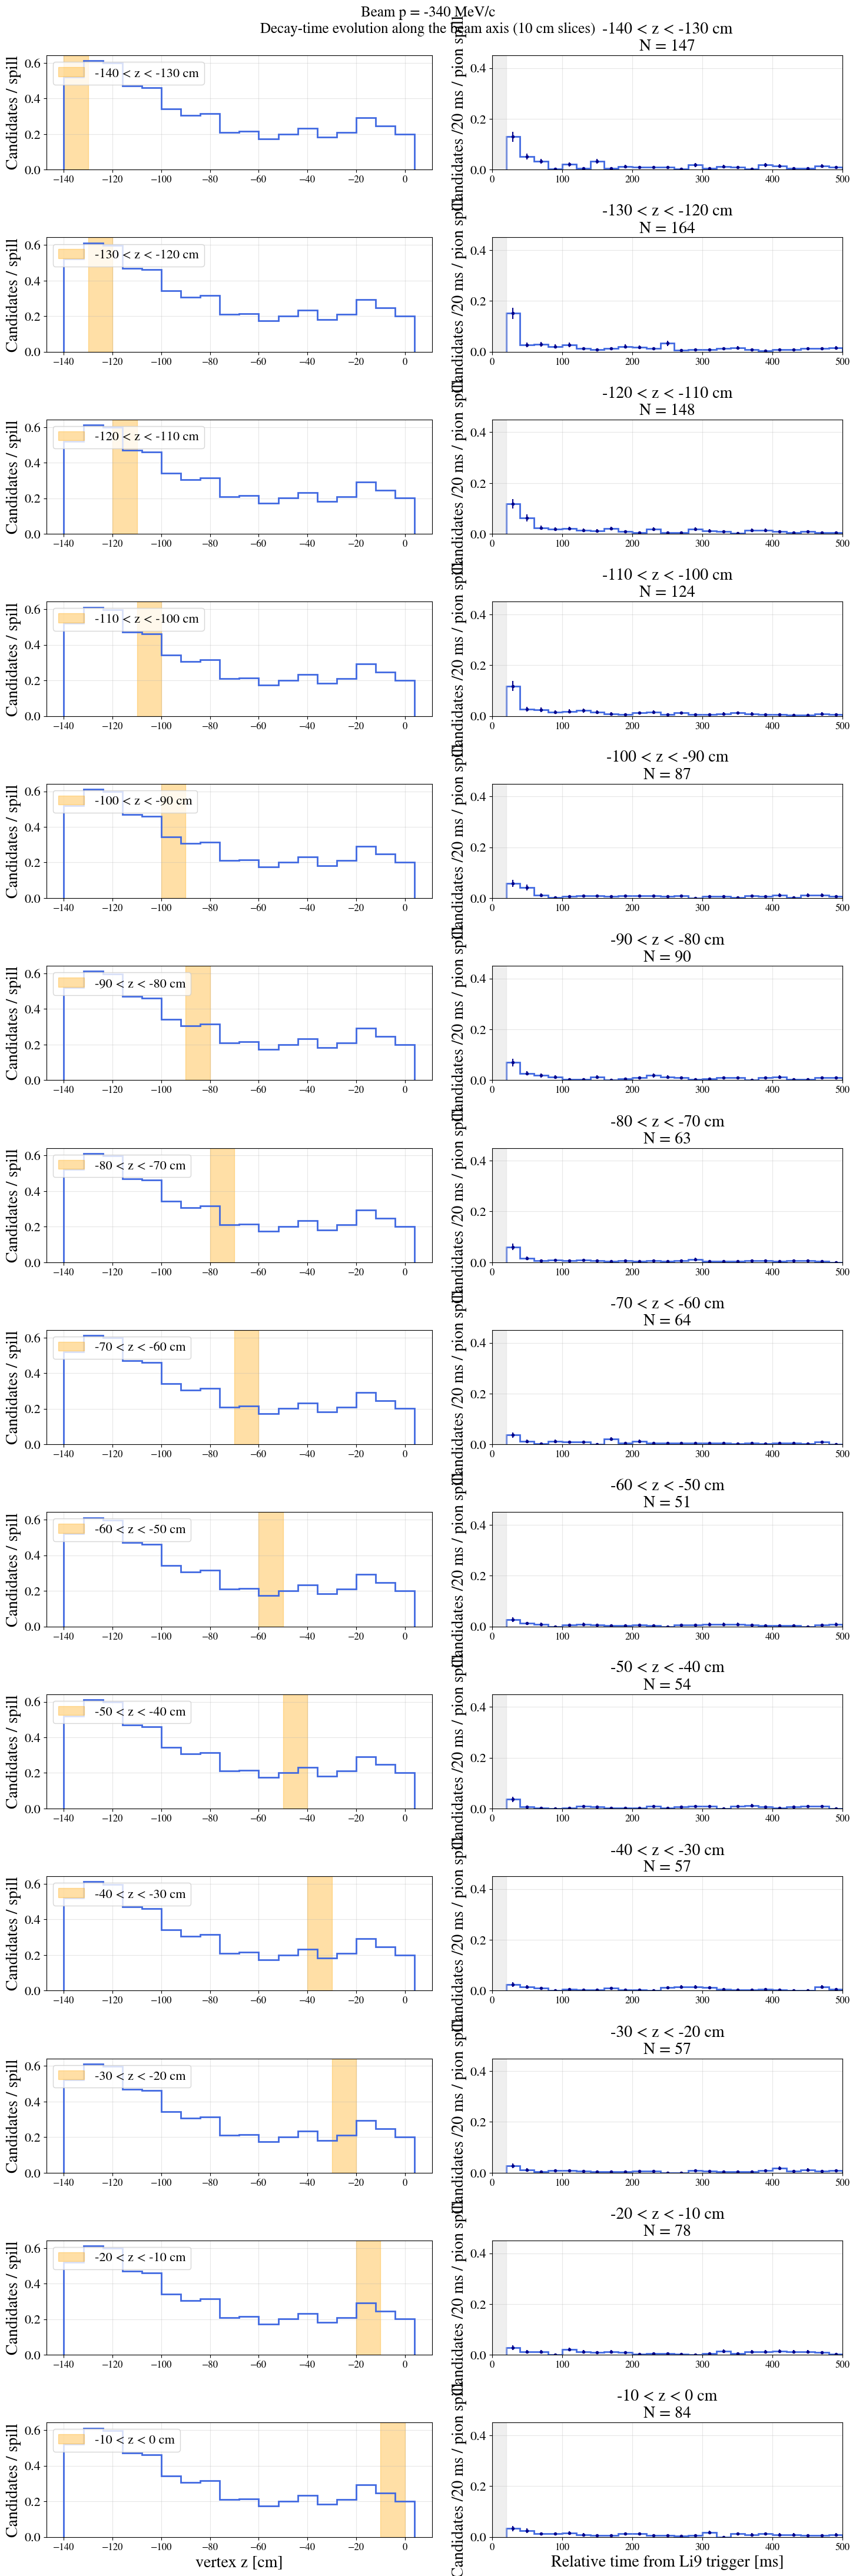

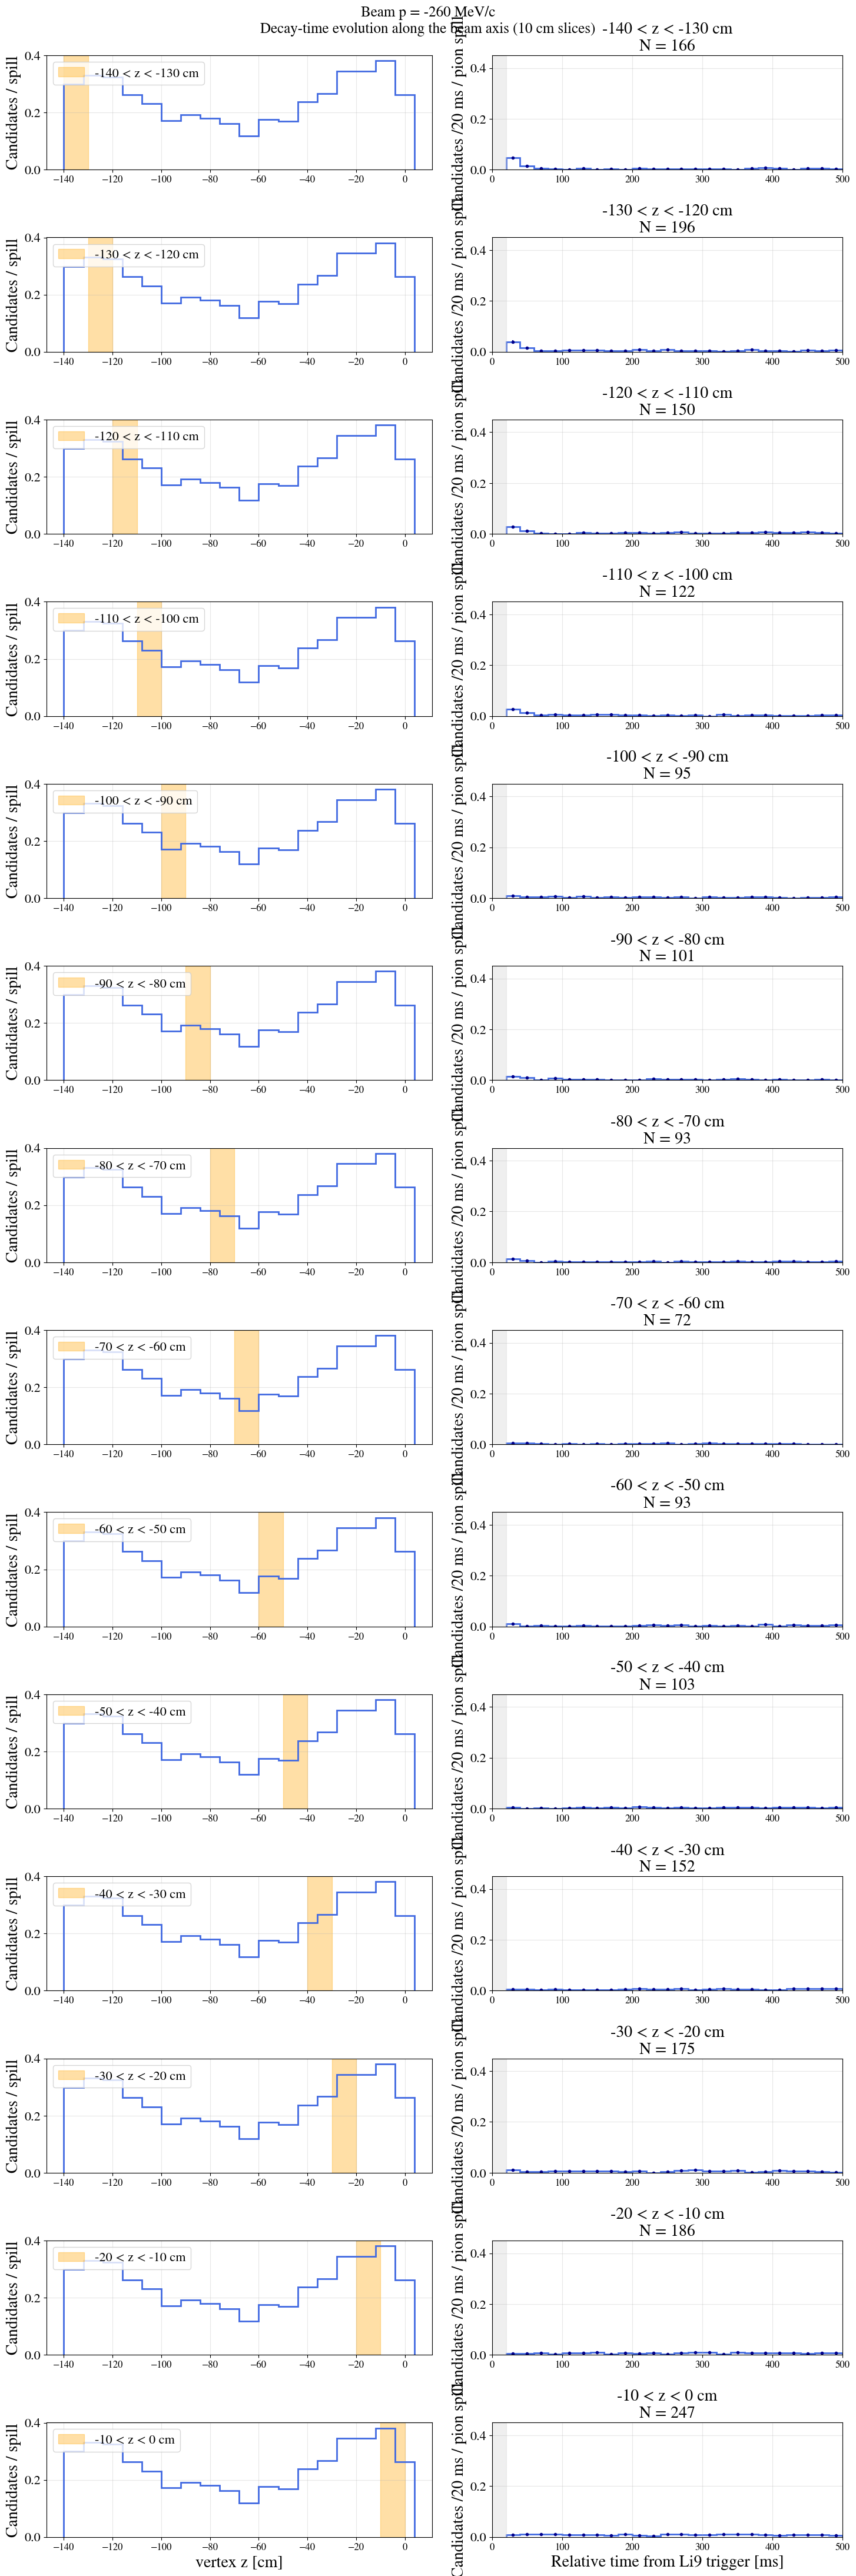

In [ ]:
# ============================================================
# Decay-time distributions in fine z slices
#
# SIGNAL ONLY
#
# 10 cm slices along the beam axis
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

time_bins = np.arange(20, 520, 20)

# 10 cm slices
z_edges = np.arange(-140, 10, 10)

time_column = "t_window_start_rel_ns"
z_column = "v_z_fine"

# Fixed y-axis (change if desired)
TIME_YMAX = 0.45


def plot_time_vs_z(df, beam_label, pion_spills):

    nregions = len(z_edges) - 1

    fig, axs = plt.subplots(
        nregions,
        2,
        figsize=(15, 3.2*nregions),
        gridspec_kw={"width_ratios":[1.1,1]}
    )

    if nregions == 1:
        axs = np.array([axs])

    # Global z histogram (same for every row)
    weights = np.ones(len(df)) / df["spill_id"].nunique()

    for i in range(nregions):

        zmin = z_edges[i]
        zmax = z_edges[i+1]

        ########################################################
        # Select events
        ########################################################

        region = df[
            (df[z_column] >= zmin) &
            (df[z_column] <  zmax)
        ]

        ########################################################
        # LEFT : z projection
        ########################################################

        ax = axs[i,0]

        ax.hist(
            df[z_column],
            bins=np.arange(-140,10,8),
            weights=weights,
            histtype="step",
            linewidth=2,
            color="royalblue"
        )

        ax.axvspan(
            zmin,
            zmax,
            color="orange",
            alpha=0.35,
            label=f"{zmin} < z < {zmax} cm"
        )

        ax.set_ylabel("Candidates / spill")

        if i == nregions-1:
            ax.set_xlabel("vertex z [cm]")

        ax.grid(alpha=0.3)
        ax.legend(loc="upper left")

        ########################################################
        # RIGHT : time distribution
        ########################################################

        ax = axs[i,1]

        t = region[time_column] / 1e6

        counts, edges = np.histogram(
            t + 20,
            bins=time_bins
        )

        centers = (edges[:-1] + edges[1:]) / 2

        counts_scaled = counts / pion_spills
        errors = np.sqrt(np.maximum(counts,1)) / pion_spills

        ax.stairs(
            counts_scaled,
            edges,
            linewidth=2,
            color="royalblue"
        )

        ax.errorbar(
            centers,
            counts_scaled,
            yerr=errors,
            fmt="o",
            color="darkblue",
            markersize=3
        )

        # rejected prompt region
        ax.axvspan(
            0,
            20,
            color="lightgray",
            alpha=0.35
        )

        ax.set_xlim(0,500)
        ax.set_ylim(0,TIME_YMAX)

        ax.grid(alpha=0.3)

        if i == nregions-1:
            ax.set_xlabel("Relative time from Li9 trigger [ms]")

        ax.set_ylabel("Candidates /20 ms / pion spill")

        ax.set_title(
            f"{zmin} < z < {zmax} cm\n"
            f"N = {len(region)}"
        )

    plt.suptitle(
        f"{beam_label}\nDecay-time evolution along the beam axis (10 cm slices)",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()


# ------------------------------------------------------------
# Draw figures
# ------------------------------------------------------------

plot_time_vs_z(
    df_340_sig_comb,
    "Beam p = -340 MeV/c",
    spills_340_pion
)

plot_time_vs_z(
    df_260_sig_comb,
    "Beam p = -260 MeV/c",
    spills_260_pion
)

In [14]:
RUNS = [1846, 1848, 1928, 1930, 1932, 1934, 1935, 1936, 1937, 1938, 1939, 1941]
BASE_DIR = "/scratch/elena/9Li/results"

def get_beam_momentum(run_id):
    if run_id in [1846, 1848]:
        return "-340 MeV/c"
    else:
        return "-260 MeV/c"

# Diccionario para almacenar los datos estructurados de ambos modos
modes_data = {
    "SIGNAL": [],
    "BACKGROUND (BKG)": []
}

for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
    is_bkg = mode == "BACKGROUND (BKG)"
    suffix = "_BKG" if is_bkg else ""
    
    for run in RUNS:
        run_folder = f"{BASE_DIR}/run{run}/processed"
        momentum = get_beam_momentum(run)
        
        # ----------------------------------------------------------------------
        # PHASE 1: ORIGINAL CHUNKS (Li9*)
        # ----------------------------------------------------------------------
        orig_pattern = os.path.join(run_folder, f"Li9_clusters_chunk*{suffix}.pkl")
        orig_files = glob.glob(orig_pattern)
        
        orig_clusters = 0
        orig_spills_set = set()
        
        for f in orig_files:
            try:
                df_chunk = pd.read_pickle(f)
                orig_clusters += len(df_chunk)
                if 'spill_id' in df_chunk.columns and len(df_chunk) > 0:
                    orig_spills_set.update(df_chunk['spill_id'].unique())
            except Exception:
                pass
        orig_spills = len(orig_spills_set) if orig_files else 0

        # ----------------------------------------------------------------------
        # PHASE 2: AFTER 1ST MULTILATERATION (Refine*)
        # ----------------------------------------------------------------------
        ref_pattern = os.path.join(run_folder, f"Refine_Li9_clusters_chunk*{suffix}.pkl")
        ref_files = glob.glob(ref_pattern)
        
        ref_clusters = 0
        ref_spills_set = set()
        
        for f in ref_files:
            try:
                df_chunk = pd.read_pickle(f)
                ref_clusters += len(df_chunk)
                if 'spill_id' in df_chunk.columns and len(df_chunk) > 0:
                    ref_spills_set.update(df_chunk['spill_id'].unique())
            except Exception:
                pass
        ref_spills = len(ref_spills_set) if ref_files else 0

        # ----------------------------------------------------------------------
        # PHASE 3: FINAL & FIDUCIAL VOLUME CUT (Final*)
        # ----------------------------------------------------------------------
        final_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}{suffix}.pkl")
        
        final_spills = 0
        final_clusters = 0
        final_20_50 = 0
        final_50_500 = 0
        
        if os.path.exists(final_file):
            try:
                df_final = pd.read_pickle(final_file)
                if not df_final.empty:
                    final_clusters = len(df_final)
                    if 'spill_id' in df_final.columns:
                        final_spills = df_final['spill_id'].nunique()
                    
                    # Corrección temporal con el offset de 20 ms
                    time_ms_corrected = (df_final["t_window_start_rel_ns"] / 1e6) + 20
                    final_20_50 = ((time_ms_corrected >= 20) & (time_ms_corrected <= 50)).sum()
                    final_50_500 = ((time_ms_corrected > 50) & (time_ms_corrected <= 500)).sum()
            except Exception:
                pass

        # Guardamos la fila con los nombres de columnas exactos solicitados
        modes_data[mode].append({
            "Run Number": f"{run}",
            "Beam p": momentum,
            "Spills (Li9*)": orig_spills,
            "Clusters (Li9*)": orig_clusters,
            "Spills (Refine*)": ref_spills,
            "Clusters (Refine*)": ref_clusters,
            "Spills (Final*)": final_spills,
            "Final c.c. (Total)": final_clusters,
            "Final c.c. (20-50ms)": final_20_50,
            "Final c.c. (50-500ms)": final_50_500
        })

# ------------------------------------------------------------------------------
# PRINTING BOTH TABLES IN ENGLISH
# ------------------------------------------------------------------------------
for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
    df_table = pd.DataFrame(modes_data[mode])
    df_table = df_table.sort_values(by="Run Number").reset_index(drop=True)
    
    print(f" DATA SAMPLE: {mode}")
    print("-" * 250)
    print(df_table.to_string(index=False))


 DATA SAMPLE: SIGNAL
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Run Number     Beam p  Spills (Li9*)  Clusters (Li9*)  Spills (Refine*)  Clusters (Refine*)  Spills (Final*)  Final c.c. (Total)  Final c.c. (20-50ms)  Final c.c. (50-500ms)
      1846 -340 MeV/c            269           553402               268               80569                0                   0                     0                      0
      1848 -340 MeV/c            249           516686               249               75392                0                   0                     0                      0
      1928 -260 MeV/c            438           490944               438              111628                0                   0                     0                      0
      1930 -260 MeV/c           

In [15]:
TARGET_RUNS = [1846, 1848]
BASE_DIR = "/scratch/elena/9Li/results"

modes_sum_data = {
    "SIGNAL": [],
    "BACKGROUND (BKG)": []
}

for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
    is_bkg = mode == "BACKGROUND (BKG)"
    suffix = "_BKG" if is_bkg else ""
    
    orig_clusters_tot = 0
    orig_spills_set = set()
    
    ref_clusters_tot = 0
    ref_spills_set = set()
    
    final_clusters_tot = 0
    final_spills_set = set()
    final_20_50_tot = 0
    final_50_500_tot = 0
    
    for run in TARGET_RUNS:
        run_folder = f"{BASE_DIR}/run{run}/processed"
        
        # 1. PHASE 1: ORIGINAL CHUNKS (Li9*)
        orig_pattern = os.path.join(run_folder, f"Li9_clusters_chunk*{suffix}.pkl")
        orig_files = glob.glob(orig_pattern)
        for f in orig_files:
            try:
                df_chunk = pd.read_pickle(f)
                orig_clusters_tot += len(df_chunk)
                if 'spill_id' in df_chunk.columns and len(df_chunk) > 0:
                    # HACEMOS EL IDENTIFICADOR ÚNICO COMBINANDO RUN + SPILL
                    unique_spills = [f"{run}_{s}" for s in df_chunk['spill_id'].unique()]
                    orig_spills_set.update(unique_spills)
            except Exception:
                pass

        # 2. PHASE 2: AFTER 1ST MULTILATERATION (Refine*)
        ref_pattern = os.path.join(run_folder, f"Refine_Li9_clusters_chunk*{suffix}.pkl")
        ref_files = glob.glob(ref_pattern)
        for f in ref_files:
            try:
                df_chunk = pd.read_pickle(f)
                ref_clusters_tot += len(df_chunk)
                if 'spill_id' in df_chunk.columns and len(df_chunk) > 0:
                    unique_spills = [f"{run}_{s}" for s in df_chunk['spill_id'].unique()]
                    ref_spills_set.update(unique_spills)
            except Exception:
                pass

        # 3. PHASE 3: FINAL & FIDUCIAL VOLUME CUT (Final*)
        final_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}{suffix}.pkl")
        if os.path.exists(final_file):
            try:
                df_final = pd.read_pickle(final_file)
                if not df_final.empty:
                    final_clusters_tot += len(df_final)
                    if 'spill_id' in df_final.columns:
                        unique_spills = [f"{run}_{s}" for s in df_final['spill_id'].unique()]
                        final_spills_set.update(unique_spills)
                    
                    time_ms_corrected = (df_final["t_window_start_rel_ns"] / 1e6) + 20
                    final_20_50_tot += ((time_ms_corrected >= 20) & (time_ms_corrected <= 50)).sum()
                    final_50_500_tot += ((time_ms_corrected > 50) & (time_ms_corrected <= 500)).sum()
            except Exception:
                pass

    modes_sum_data[mode].append({
        "Run": "1846 + 1848",
        "Beam p": "-340 MeV/c",
        "Spills (Li9*)": len(orig_spills_set),
        "Clusters (Li9*)": orig_clusters_tot,
        "Spills (Refine*)": len(ref_spills_set),
        "Clusters (Refine*)": ref_clusters_tot,
        "Spills (Final*)": len(final_spills_set),
        "Total c.c.": final_clusters_tot,
        "20-50ms": final_20_50_tot,
        "50-500ms": final_50_500_tot
    })

for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
    df_table = pd.DataFrame(modes_sum_data[mode])
    print(f"\n------------------------------- SUMMARY TABLE ({mode}) -----------------------------------------------------------")
    print(df_table.to_string(index=False))


------------------------------- SUMMARY TABLE (SIGNAL) -----------------------------------------------------------
        Run     Beam p  Spills (Li9*)  Clusters (Li9*)  Spills (Refine*)  Clusters (Refine*)  Spills (Final*)  Total c.c.  20-50ms  50-500ms
1846 + 1848 -340 MeV/c            518          1070088               517              155961                0           0        0         0

------------------------------- SUMMARY TABLE (BACKGROUND (BKG)) -----------------------------------------------------------
        Run     Beam p  Spills (Li9*)  Clusters (Li9*)  Spills (Refine*)  Clusters (Refine*)  Spills (Final*)  Total c.c.  20-50ms  50-500ms
1846 + 1848 -340 MeV/c            196           181934               195               53409                0           0        0         0


In [16]:
target_runs = [1846, 1848]
base_dir = "/scratch/elena/9Li/results"
master_table_path = "/scratch/elena/9Li/results/isotopes_output/master_table_all_runs.csv"

# --- Dynamic retrieval of pion spills ---
if not os.path.exists(master_table_path):
    raise FileNotFoundError(
        f"Master table not found at '{master_table_path}'. "
        f"Make sure you have merged the individual csv files first."
    )

df_master = pd.read_csv(master_table_path)

# Filter the master table to keep only the selected target runs
df_target = df_master[df_master["Run"].isin(target_runs)]

if df_target.empty:
    raise ValueError(
        f"None of the specified runs {target_runs} were found in the master table. "
        f"Please check the run numbers."
    )

# Dynamically sum the spills for all runs included in the list
pion_spills_total = df_target["N spills with pions"].sum()

# Extract beam momentum automatically from the first run for the summary table
beam_p_label = df_target.iloc[0]["Beam p (MeV/c)"]
beam_p_str = f"{beam_p_label} MeV/c"

print(f"--> [OK] Found {len(df_target)} runs in the master table.")
print(f"--> Using a total of {pion_spills_total} spills with pions for scaling.")


modes_sum_data = {
    "SIGNAL": [],
    "BACKGROUND (BKG)": []
}

for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
    is_bkg = mode == "BACKGROUND (BKG)"
    suffix = "_BKG" if is_bkg else ""
    
    orig_clusters_tot = 0
    ref_clusters_tot = 0
    final_clusters_tot = 0
    final_20_50_tot = 0
    final_50_500_tot = 0
    
    for run in target_runs:
        run_folder = f"{base_dir}/run{run}/processed"
        
        # 1. Phase 1: Original chunks (Li9*)
        orig_pattern = os.path.join(run_folder, f"Li9_clusters_chunk*{suffix}.pkl")
        orig_files = glob.glob(orig_pattern)
        for f in orig_files:
            try:
                df_chunk = pd.read_pickle(f)
                orig_clusters_tot += len(df_chunk)
            except Exception:
                pass

        # 2. Phase 2: After 1st multilateration (Refine*)
        ref_pattern = os.path.join(run_folder, f"Refine_Li9_clusters_chunk*{suffix}.pkl")
        ref_files = glob.glob(ref_pattern)
        for f in ref_files:
            try:
                df_chunk = pd.read_pickle(f)
                ref_clusters_tot += len(df_chunk)
            except Exception:
                pass

        # 3. Phase 3: Final & fiducial volume cut (Final*)
        final_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}{suffix}.pkl")
        if os.path.exists(final_file):
            try:
                df_final = pd.read_pickle(final_file)
                if not df_final.empty:
                    final_clusters_tot += len(df_final)
                    
                    time_ms_corrected = (df_final["t_window_start_rel_ns"] / 1e6) + 20
                    final_20_50_tot += ((time_ms_corrected >= 20) & (time_ms_corrected <= 50)).sum()
                    final_50_500_tot += ((time_ms_corrected > 50) & (time_ms_corrected <= 500)).sum()
            except Exception:
                pass

    # Automatically generate the combined run label (e.g., "1846 + 1848")
    run_label = " + ".join(str(r) for r in target_runs)

    modes_sum_data[mode].append({
        "Runs combined": run_label,
        "Beam p": beam_p_str,
        "N spills (pions)": pion_spills_total,
        "Clusters/spill (orig)": round(orig_clusters_tot / pion_spills_total, 2),
        "Clusters/spill (refine)": round(ref_clusters_tot / pion_spills_total, 2),
        "Total c.c./spill": round(final_clusters_tot / pion_spills_total, 4),
        "20-50ms/spill": round(final_20_50_tot / pion_spills_total, 4),
        "50-500ms/spill": round(final_50_500_tot / pion_spills_total, 4)
    })


for mode in ["SIGNAL", "BACKGROUND (BKG)"]:
    df_table = pd.DataFrame(modes_sum_data[mode])
    print(f"\n--- Summary table scaled by pion spills ({mode.lower()}) ---")
    print("-" * 115)
    print(df_table.to_string(index=False))

--> [OK] Found 2 runs in the master table.
--> Using a total of 330.0 spills with pions for scaling.

--- Summary table scaled by pion spills (signal) ---
-------------------------------------------------------------------------------------------------------------------
Runs combined       Beam p  N spills (pions)  Clusters/spill (orig)  Clusters/spill (refine)  Total c.c./spill  20-50ms/spill  50-500ms/spill
  1846 + 1848 -340.0 MeV/c             330.0                3242.69                   472.61               0.0            0.0             0.0

--- Summary table scaled by pion spills (background (bkg)) ---
-------------------------------------------------------------------------------------------------------------------
Runs combined       Beam p  N spills (pions)  Clusters/spill (orig)  Clusters/spill (refine)  Total c.c./spill  20-50ms/spill  50-500ms/spill
  1846 + 1848 -340.0 MeV/c             330.0                 551.32                   161.85               0.0            0

# FITS (INDEPENDET FITS AND DOUBLE EXPONENTIAL FIT + UNBINNED)

/tmp/ipykernel_627151/4166983912.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_r1, pcov_r1 = curve_fit(


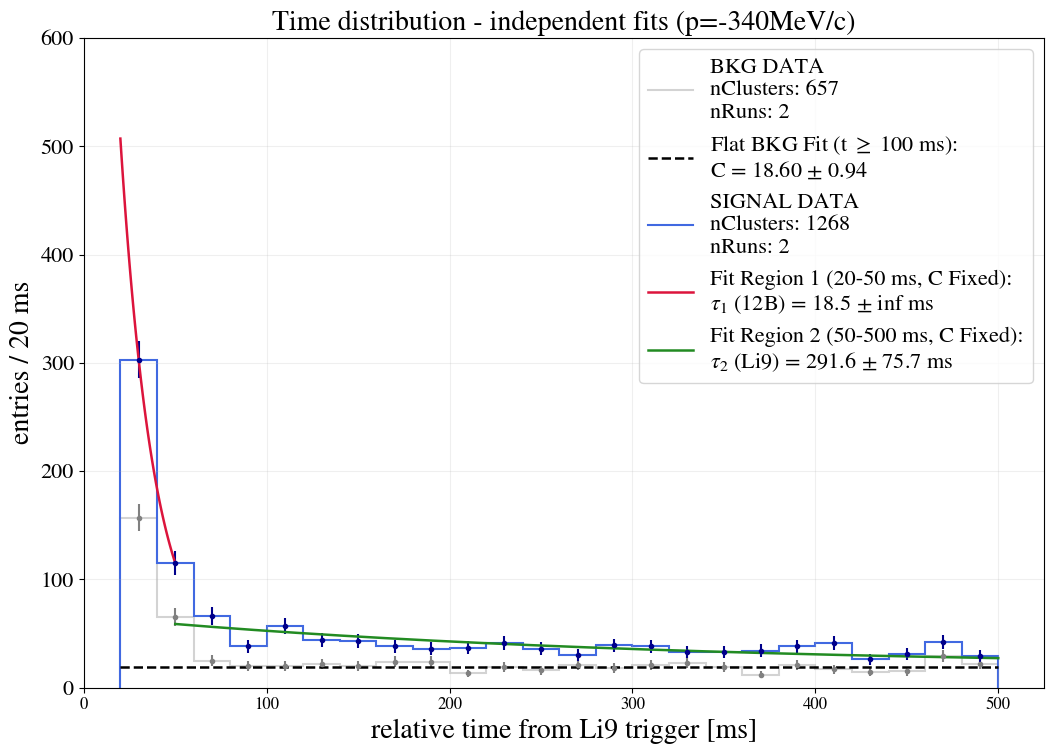

In [ ]:
RUNS_340 = [1846, 1848]   #only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()


bin_width = 20 #ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  #offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))


# FIT 1 ---> flat BKG --> C

t_cut_bkg = 100  #excluyendo primeros bins 
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])
#print(f"C = {C_const:.2f} ± {C_err:.2f}")

# FIT 2 --> curve fit --> 2 independientes con C fija para ambos

def exp_with_c(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const

#region (20-50 ms)
mask_r1 = (bin_centers >= 20) & (bin_centers <= 50)

popt_r1, pcov_r1 = curve_fit(
    exp_with_c,
    bin_centers[mask_r1],
    counts_sig[mask_r1],
    sigma=errors_sig[mask_r1],
    p0=[400.0, 20.0],
    bounds=([0, 2], [5000, 200])
)
A_fit, tau1_fit = popt_r1
tau1_err = np.sqrt(pcov_r1[1, 1])

#region (50-500ms)
mask_r2 = bin_centers >= 50

popt_r2, pcov_r2 = curve_fit(
    exp_with_c,
    bin_centers[mask_r2],
    counts_sig[mask_r2],
    sigma=errors_sig[mask_r2],
    p0=[100.0, 170.0],
    bounds=([0, 30], [1000, 3000])
)
B_fit, tau2_fit = popt_r2
tau2_err = np.sqrt(pcov_r2[1, 1])

# Final PLOT

rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

#bkg
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

#flat bkg (C)
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

#signal
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")

#curve fit (20-50ms)
t_plot_r1 = np.linspace(20, 50, 100)
ax.plot(t_plot_r1, exp_with_c(t_plot_r1, *popt_r1), color="crimson", linewidth=1.8,
        label=f"Fit Region 1 (20-50 ms, C Fixed):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms")

#curve fit (50-500ms)
t_plot_r2 = np.linspace(50, 500, 1000)
ax.plot(t_plot_r2, exp_with_c(t_plot_r2, *popt_r2), color="forestgreen", linewidth=1.8,
        label=f"Fit Region 2 (50-500 ms, C Fixed):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms")


ax.set_title("Time distribution - independent fits (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)
ax.set_ylim(0, 600) #fixed ylim
ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

/tmp/ipykernel_627151/1063129637.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_r1, pcov_r1 = curve_fit(
/tmp/ipykernel_627151/1063129637.py:128: RuntimeWarning: divide by zero encountered in scalar divide
  label=f"Fit Region 1 (20-50 ms, C Fixed):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")


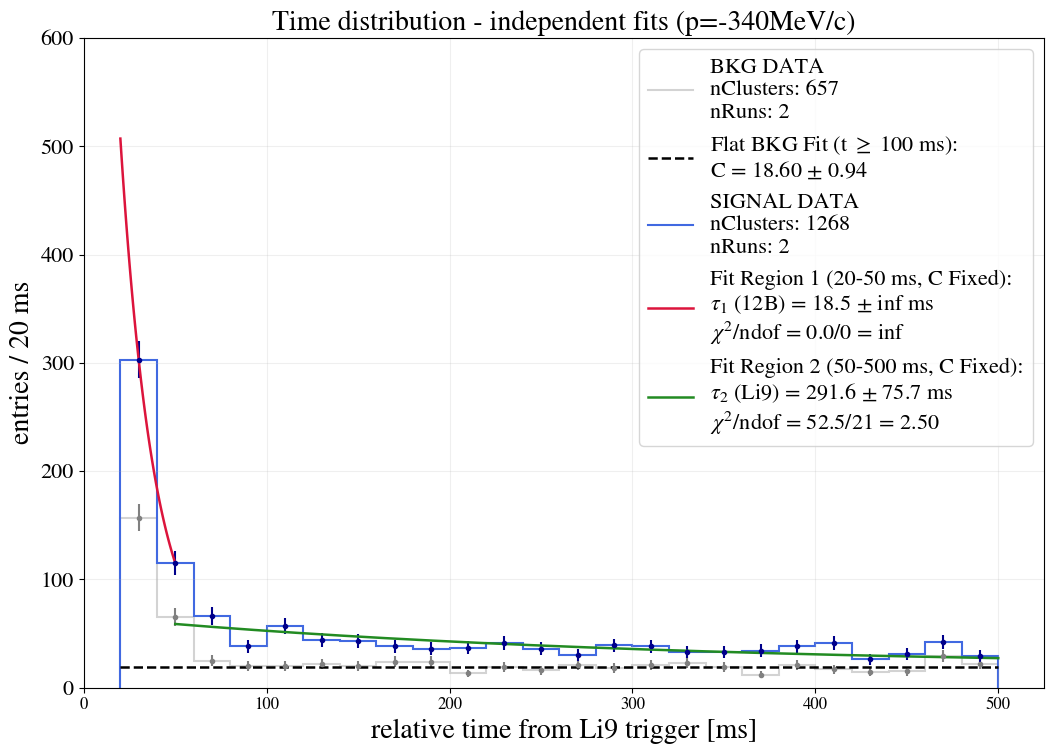

In [ ]:
RUNS_340 = [1846, 1848]   #only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()


bin_width = 20 #ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  #offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))


# FIT 1 ---> flat BKG --> C

t_cut_bkg = 100  #excluyendo primeros bins 
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])
#print(f"C = {C_const:.2f} ± {C_err:.2f}")

# FIT 2 --> curve fit --> 2 independientes con C fija para ambos

def exp_with_c(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const

#region (20-50 ms)
mask_r1 = (bin_centers >= 20) & (bin_centers <= 50)

popt_r1, pcov_r1 = curve_fit(
    exp_with_c,
    bin_centers[mask_r1],
    counts_sig[mask_r1],
    sigma=errors_sig[mask_r1],
    p0=[400.0, 20.0],
    bounds=([0, 2], [5000, 200])
)
A_fit, tau1_fit = popt_r1
tau1_err = np.sqrt(pcov_r1[1, 1])

# --- CÁLCULO DE CHI2 PARA REGIÓN 1 ---
pred_r1 = exp_with_c(bin_centers[mask_r1], *popt_r1)
chi2_r1 = np.sum(((counts_sig[mask_r1] - pred_r1) / errors_sig[mask_r1])**2)
ndof_r1 = len(bin_centers[mask_r1]) - 2  # 2 parámetros libres (Amplitude, tau)


#region (50-500ms)
mask_r2 = bin_centers >= 50

popt_r2, pcov_r2 = curve_fit(
    exp_with_c,
    bin_centers[mask_r2],
    counts_sig[mask_r2],
    sigma=errors_sig[mask_r2],
    p0=[100.0, 170.0],
    bounds=([0, 30], [1000, 3000])
)
B_fit, tau2_fit = popt_r2
tau2_err = np.sqrt(pcov_r2[1, 1])

# --- CÁLCULO DE CHI2 PARA REGIÓN 2 ---
pred_r2 = exp_with_c(bin_centers[mask_r2], *popt_r2)
chi2_r2 = np.sum(((counts_sig[mask_r2] - pred_r2) / errors_sig[mask_r2])**2)
ndof_r2 = len(bin_centers[mask_r2]) - 2  # 2 parámetros libres (Amplitude, tau)


# Final PLOT

rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

#bkg
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

#flat bkg (C)
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

#signal
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")

#curve fit (20-50ms)
t_plot_r1 = np.linspace(20, 50, 100)
ax.plot(t_plot_r1, exp_with_c(t_plot_r1, *popt_r1), color="crimson", linewidth=1.8,
        label=f"Fit Region 1 (20-50 ms, C Fixed):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")

#curve fit (50-500ms)
t_plot_r2 = np.linspace(50, 500, 1000)
ax.plot(t_plot_r2, exp_with_c(t_plot_r2, *popt_r2), color="forestgreen", linewidth=1.8,
        label=f"Fit Region 2 (50-500 ms, C Fixed):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r2:.1f}/{ndof_r2} = {chi2_r2/ndof_r2:.2f}")


ax.set_title("Time distribution - independent fits (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)
ax.set_ylim(0, 600) #fixed ylim
ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

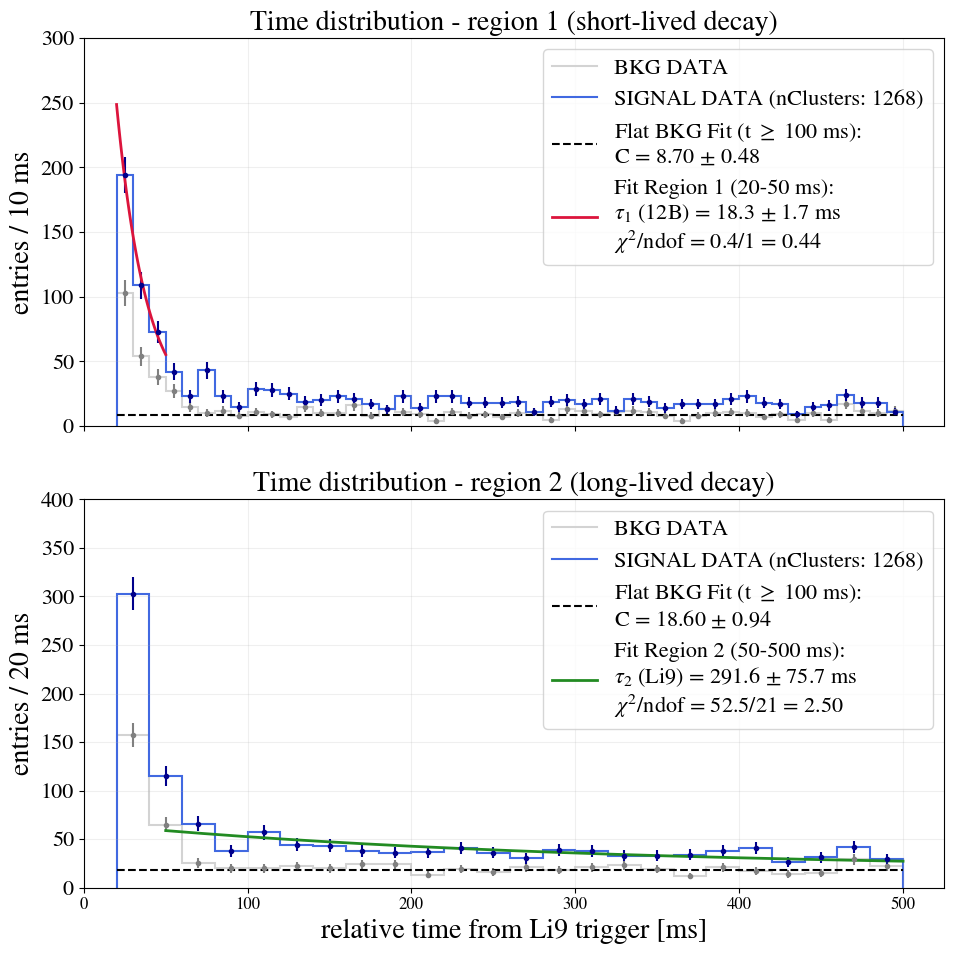

In [ ]:
RUNS_340 = [1846, 1848]   #only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()

time_column = "t_window_start_rel_ns"
times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  #offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20


# ==========================================
# 1. PREPARACIÓN DE DATOS POR REGIÓN
# ==========================================

# --- Datos Región 1 (Ancho de bin = 10 ms) ---
bw1 = 10
bins1 = np.arange(20, 500 + bw1, bw1)
counts_sig1, bin_edges1 = np.histogram(times_sig_ms, bins=bins1)
counts_bkg1, _ = np.histogram(times_bkg_ms, bins=bins1)
bin_centers1 = (bin_edges1[:-1] + bin_edges1[1:]) / 2
errors_sig1 = np.sqrt(np.maximum(counts_sig1, 1))
errors_bkg1 = np.sqrt(np.maximum(counts_bkg1, 1))

# --- Datos Región 2 (Ancho de bin = 20 ms) ---
bw2 = 20
bins2 = np.arange(20, 500 + bw2, bw2)
counts_sig2, bin_edges2 = np.histogram(times_sig_ms, bins=bins2)
counts_bkg2, _ = np.histogram(times_bkg_ms, bins=bins2)
bin_centers2 = (bin_edges2[:-1] + bin_edges2[1:]) / 2
errors_sig2 = np.sqrt(np.maximum(counts_sig2, 1))
errors_bkg2 = np.sqrt(np.maximum(counts_bkg2, 1))


# ==========================================
# 2. CÁLCULO DE LOS AJUSTES (FITS)
# ==========================================

def flat_func(t, c):
    return np.full_like(t, c)

# ------------------------------------------
# AJUSTES PARA EL SUBPLOT 1 (Binado de 10 ms)
# ------------------------------------------
# A) Extraer C_const directamente del BKG binned a 10ms para t >= 100ms
mask_bkg_fit1 = bin_centers1 >= 100
popt_bkg1, pcov_bkg1 = curve_fit(
    flat_func, bin_centers1[mask_bkg_fit1], counts_bkg1[mask_bkg_fit1], 
    sigma=errors_bkg1[mask_bkg_fit1], p0=[np.mean(counts_bkg1[mask_bkg_fit1])]
)
C_const_r1 = popt_bkg1[0]
C_err_r1 = np.sqrt(pcov_bkg1[0, 0])

# B) Fit Exponencial Región 1 (20-50 ms) con su respectiva C fija
mask_r1 = (bin_centers1 >= 20) & (bin_centers1 <= 50)

def exp_with_c_r1(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const_r1

popt_r1, pcov_r1 = curve_fit(
    exp_with_c_r1, bin_centers1[mask_r1], counts_sig1[mask_r1], sigma=errors_sig1[mask_r1],
    p0=[400.0, 20.0], bounds=([0, 2], [5000, 200])
)
A_fit, tau1_fit = popt_r1
tau1_err = np.sqrt(pcov_r1[1, 1])

pred_r1 = exp_with_c_r1(bin_centers1[mask_r1], *popt_r1)
chi2_r1 = np.sum(((counts_sig1[mask_r1] - pred_r1) / errors_sig1[mask_r1])**2)
ndof_r1 = len(bin_centers1[mask_r1]) - 2


# ------------------------------------------
# AJUSTES PARA EL SUBPLOT 2 (Binado de 20 ms)
# ------------------------------------------
# A) Extraer C_const directamente del BKG binned a 20ms para t >= 100ms
mask_bkg_fit2 = bin_centers2 >= 100
popt_bkg2, pcov_bkg2 = curve_fit(
    flat_func, bin_centers2[mask_bkg_fit2], counts_bkg2[mask_bkg_fit2], 
    sigma=errors_bkg2[mask_bkg_fit2], p0=[np.mean(counts_bkg2[mask_bkg_fit2])]
)
C_const_r2 = popt_bkg2[0]
C_err_r2 = np.sqrt(pcov_bkg2[0, 0])

# B) Fit Exponencial Región 2 (50-500 ms) con su respectiva C fija
mask_r2 = bin_centers2 >= 50

def exp_with_c_r2(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const_r2

popt_r2, pcov_r2 = curve_fit(
    exp_with_c_r2, bin_centers2[mask_r2], counts_sig2[mask_r2], sigma=errors_sig2[mask_r2],
    p0=[100.0, 170.0], bounds=([0, 30], [1000, 3000])
)
B_fit, tau2_fit = popt_r2
tau2_err = np.sqrt(pcov_r2[1, 1])

pred_r2 = exp_with_c_r2(bin_centers2[mask_r2], *popt_r2)
chi2_r2 = np.sum(((counts_sig2[mask_r2] - pred_r2) / errors_sig2[mask_r2])**2)
ndof_r2 = len(bin_centers2[mask_r2]) - 2


# ==========================================
# 3. GENERACIÓN DEL PLOT (2 SUBPLOTS)
# ==========================================
rcParams['figure.figsize'] = [10, 10]
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)

t_range = np.linspace(20, 500, 1000)

# ------------------------------------------
# SUBPLOT 1: REGIÓN 1 (Bines de 10 ms)
# ------------------------------------------
ax1.stairs(counts_bkg1, bin_edges1, color="lightgray", linewidth=1.5, label="BKG DATA")
ax1.errorbar(bin_centers1, counts_bkg1, yerr=errors_bkg1, fmt="o", color="gray", markersize=3, ls="none")

ax1.stairs(counts_sig1, bin_edges1, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax1.errorbar(bin_centers1, counts_sig1, yerr=errors_sig1, fmt="o", color="darkblue", markersize=3, ls="none")

# Línea de fondo calculada sobre la muestra BKG (10ms, t >= 100ms)
ax1.plot(t_range, flat_func(t_range, C_const_r1), color="black", linestyle="--", linewidth=1.5,
         label=f"Flat BKG Fit (t $\geq$ 100 ms):\nC = {C_const_r1:.2f} $\pm$ {C_err_r1:.2f}")

# Ajuste exponencial R1 (20-50 ms)
t_plot_r1 = np.linspace(20, 50, 100)
ax1.plot(t_plot_r1, exp_with_c_r1(t_plot_r1, *popt_r1), color="crimson", linewidth=2,
         label=f"Fit Region 1 (20-50 ms):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")

ax1.set_title("Time distribution - region 1 (short-lived decay)")
ax1.set_ylabel(f"entries / {bw1} ms")
ax1.set_ylim(0, 300) 
ax1.grid(True, which="both", linestyle="-", alpha=0.2)
ax1.legend(loc="upper right", frameon=True)


# ------------------------------------------
# SUBPLOT 2: REGIÓN 2 (Bines de 20 ms)
# ------------------------------------------
ax2.stairs(counts_bkg2, bin_edges2, color="lightgray", linewidth=1.5, label="BKG DATA")
ax2.errorbar(bin_centers2, counts_bkg2, yerr=errors_bkg2, fmt="o", color="gray", markersize=3, ls="none")

ax2.stairs(counts_sig2, bin_edges2, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax2.errorbar(bin_centers2, counts_sig2, yerr=errors_sig2, fmt="o", color="darkblue", markersize=3, ls="none")

# Línea de fondo calculada sobre la muestra BKG (20ms, t >= 100ms)
ax2.plot(t_range, flat_func(t_range, C_const_r2), color="black", linestyle="--", linewidth=1.5,
         label=f"Flat BKG Fit (t $\geq$ 100 ms):\nC = {C_const_r2:.2f} $\pm$ {C_err_r2:.2f}")

# Ajuste exponencial R2 (50-500 ms)
t_plot_r2 = np.linspace(50, 500, 1000)
ax2.plot(t_plot_r2, exp_with_c_r2(t_plot_r2, *popt_r2), color="forestgreen", linewidth=2,
         label=f"Fit Region 2 (50-500 ms):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r2:.1f}/{ndof_r2} = {chi2_r2/ndof_r2:.2f}")

ax2.set_title("Time distribution - region 2 (long-lived decay)")
ax2.set_xlabel("relative time from Li9 trigger [ms]")
ax2.set_ylabel(f"entries / {bw2} ms")
ax2.set_xlim(0, 525)
ax2.set_ylim(0, 400) 
ax2.grid(True, which="both", linestyle="-", alpha=0.2)
ax2.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

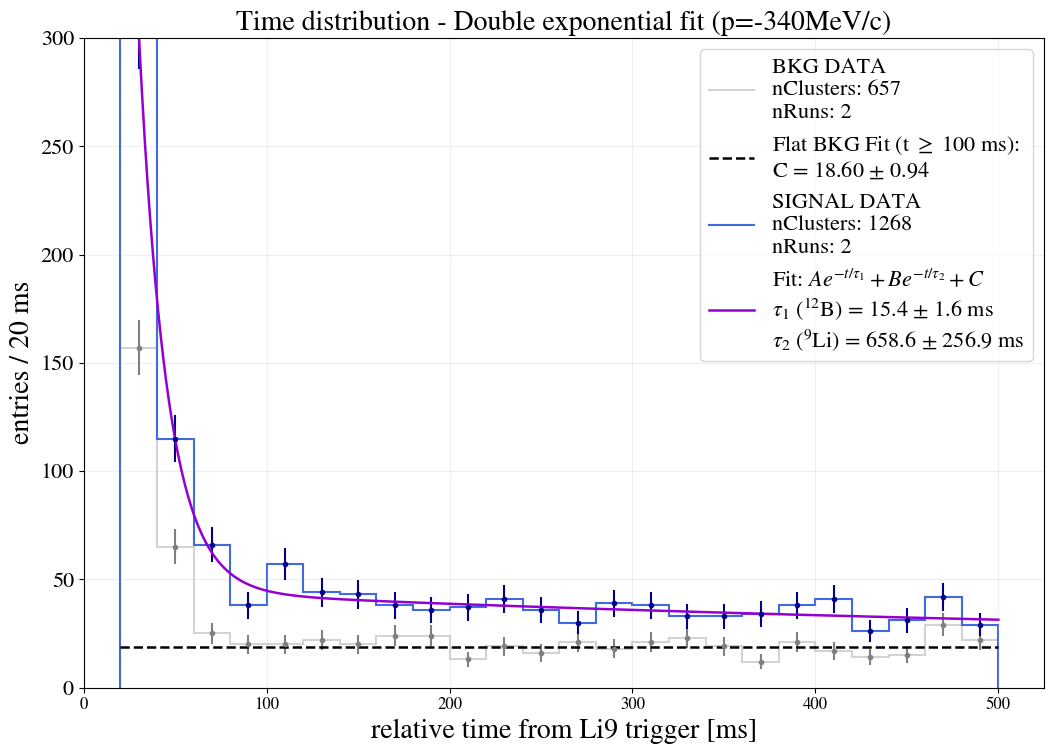

In [ ]:
bin_width = 20  
bins = np.arange(20, 500 + bin_width, bin_width)


#GLOBLA FIT with fixed C

def double_exp_with_c(t, A, tau1, B, tau2):
    return A * np.exp(-t / tau1) + B * np.exp(-t / tau2) + C_const

#all bins within the entire range 
mask_global = (bin_centers >= 20) & (bin_centers <= 500)

#initial seeds: p0 = [A, tau1, B, tau2]
p0_global = [400.0, 20.0, 100.0, 170.0]
bounds_global = (
    [0, 2, 0, 30],         #inf lim
    [5000, 200, 1000, 3000] #sup lim
)

popt_g, pcov_g = curve_fit(
    double_exp_with_c,
    bin_centers[mask_global],
    counts_sig[mask_global],
    sigma=errors_sig[mask_global],
    p0=p0_global,
    bounds=bounds_global
)

#parámetros y sus errores asociados (raíz de la diagonal de la covarianza)
A_fit, tau1_fit, B_fit, tau2_fit = popt_g
A_err, tau1_err, B_err, tau2_err = np.sqrt(np.diag(pcov_g))

#print(f"12B --> Amplitud A = {A_fit:.1f} ± {A_err:.1f} | tau_1 = {tau1_fit:.1f} ± {tau1_err:.1f} ms")
#print(f"Li9 --> Amplitud B = {B_fit:.1f} ± {B_err:.1f} | tau_2 = {tau2_fit:.1f} ± {tau2_err:.1f} ms")

# final PLOT

rcParams['figure.figsize'] = [11, 8]
fig, ax = plt.subplots()

#bkg
ax.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, 
          label=f"BKG DATA\nnClusters: {len(df_bkg_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")

#C
t_plot_bkg = np.linspace(20, 500, 1000)
ax.plot(t_plot_bkg, flat_func(t_plot_bkg, C_const), color="black", linestyle="--", linewidth=1.8,
        label=f"Flat BKG Fit (t $\geq$ {t_cut_bkg} ms):\nC = {C_const:.2f} $\pm$ {C_err:.2f}")

# signal
ax.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, 
          label=f"SIGNAL DATA\nnClusters: {len(df_sig_total)}\nnRuns: {len(RUNS_340)}")
ax.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")


#doble exponential fit for the entire range
t_plot_global = np.linspace(20, 500, 1000)
label_fit = (
    f"Fit: $A e^{{-t/\\tau_1}} + B e^{{-t/\\tau_2}} + C$\n"
    f"$\\tau_1$ ($^{{12}}$B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n"
    f"$\\tau_2$ ($^{9}$Li) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms"
)
ax.plot(t_plot_global, double_exp_with_c(t_plot_global, *popt_g), color="darkviolet", linewidth=1.8, label=label_fit)


ax.set_title("Time distribution - Double exponential fit (p=-340MeV/c)")
ax.set_xlabel("relative time from Li9 trigger [ms]")
ax.set_ylabel(f"entries / {bin_width} ms")
ax.set_xlim(0, 525)
ax.set_ylim(0, 300) # Mantengo tu límite superior a 300 para limpieza visual

ax.grid(True, which="both", linestyle="-", alpha=0.2)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

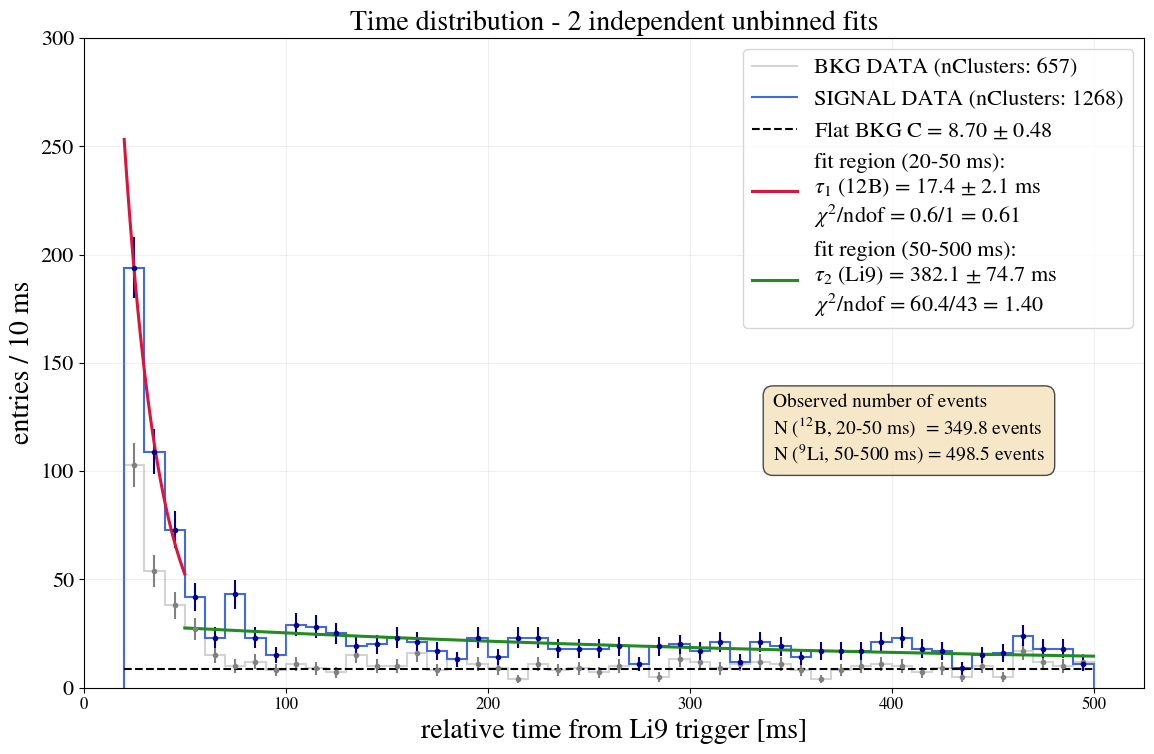

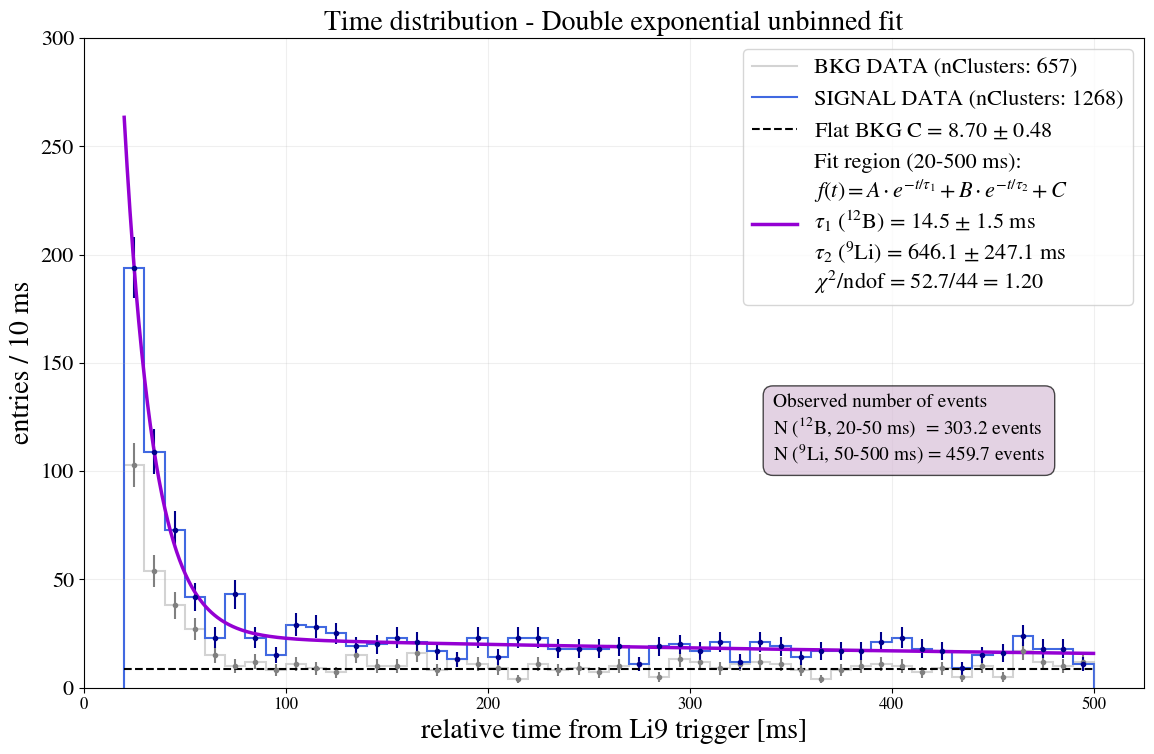

In [ ]:
RUNS_340 = [1846, 1848]   # only this Beam p (from the previous step)
dfs_340_sig = []
dfs_340_bkg = []

for run in RUNS_340:
    run_folder = f"{BASE_DIR}/run{run}/processed"
    sig_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}.pkl")
    bkg_file = os.path.join(run_folder, f"Final_FV_Li9_clusters_run{run}_BKG.pkl")
    
    if os.path.exists(sig_file):
        df_sig = pd.read_pickle(sig_file)
        if not df_sig.empty:
            df_sig['origin_run'] = run
            dfs_340_sig.append(df_sig)
            
    if os.path.exists(bkg_file):
        df_bkg = pd.read_pickle(bkg_file)
        if not df_bkg.empty:
            df_bkg['origin_run'] = run
            dfs_340_bkg.append(df_bkg)

df_sig_total = pd.concat(dfs_340_sig, ignore_index=True) if dfs_340_sig else pd.DataFrame()
df_bkg_total = pd.concat(dfs_340_bkg, ignore_index=True) if dfs_340_bkg else pd.DataFrame()


bin_width = 10 # ms
bins = np.arange(20, 500 + bin_width, bin_width)
time_column = "t_window_start_rel_ns"

times_sig_ms = (df_sig_total[time_column] / 1e6) + 20  # offset 20ms
times_bkg_ms = (df_bkg_total[time_column] / 1e6) + 20

counts_sig, bin_edges = np.histogram(times_sig_ms, bins=bins)
counts_bkg, _ = np.histogram(times_bkg_ms, bins=bins)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
errors_sig = np.sqrt(np.maximum(counts_sig, 1))
errors_bkg = np.sqrt(np.maximum(counts_bkg, 1))


# ==========================================
# 1. FIT PREVIO DE FONDO PLANO (C)
# ==========================================
t_cut_bkg = 100  
mask_bkg_fit = bin_centers >= t_cut_bkg

def flat_func(t, c):
    return np.full_like(t, c)

popt_bkg, pcov_bkg = curve_fit(
    flat_func, 
    bin_centers[mask_bkg_fit], 
    counts_bkg[mask_bkg_fit], 
    sigma=errors_bkg[mask_bkg_fit],
    p0=[np.mean(counts_bkg[mask_bkg_fit])]
)
C_const = popt_bkg[0]
C_err = np.sqrt(pcov_bkg[0, 0])


# ==========================================
# 2. DEFINICIÓN DE FUNCIONES PARA AJUSTES UNBINNED
# ==========================================

# Verosimilitud logarítmica negativa extendida (1 Exponencial + C)
def extended_nll(params, times, t_min, t_max, C, dt):
    Amp, tau = params
    if Amp < 0 or tau <= 0:
        return 1e10
    
    n_exp = (Amp * tau / dt) * (np.exp(-t_min / tau) - np.exp(-t_max / tau)) + (C / dt) * (t_max - t_min)
    lambda_i = (Amp / dt) * np.exp(-times / tau) + (C / dt)
    
    if np.any(lambda_i <= 0):
        return 1e10
    return n_exp - np.sum(np.log(lambda_i))

# Verosimilitud logarítmica negativa extendida GLOBAL (Doble Exponencial + C)
def extended_nll_global(params, times, t_min, t_max, C, dt):
    Amp1, tau1, Amp2, tau2 = params
    if Amp1 < 0 or tau1 <= 0 or Amp2 < 0 or tau2 <= 0:
        return 1e10
    
    n_exp = ((Amp1 * tau1 / dt) * (np.exp(-t_min / tau1) - np.exp(-t_max / tau1)) + 
             (Amp2 * tau2 / dt) * (np.exp(-t_min / tau2) - np.exp(-t_max / tau2)) + 
             (C / dt) * (t_max - t_min))
    
    lambda_i = (Amp1 / dt) * np.exp(-times / tau1) + (Amp2 / dt) * np.exp(-times / tau2) + (C / dt)
    
    if np.any(lambda_i <= 0):
        return 1e10
    return n_exp - np.sum(np.log(lambda_i))

# Función para calcular errores numéricos usando la Hessiana
def compute_mle_errors(f, x, args):
    n = len(x)
    hessian = np.zeros((n, n))
    eps = 1e-4 * np.maximum(np.abs(x), 1e-3)
    for i in range(n):
        for j in range(n):
            if i == j:
                x_plus, x_minus = np.array(x, dtype=float), np.array(x, dtype=float)
                x_plus[i] += eps[i]; x_minus[i] -= eps[i]
                hessian[i, i] = (f(x_plus, *args) - 2 * f(x, *args) + f(x_minus, *args)) / (eps[i] ** 2)
            else:
                x_pp, x_pm, x_mp, x_mm = [np.array(x, dtype=float) for _ in range(4)]
                x_pp[i] += eps[i]; x_pp[j] += eps[j]
                x_pm[i] += eps[i]; x_pm[j] -= eps[j]
                x_mp[i] -= eps[i]; x_mp[j] += eps[j]
                x_mm[i] -= eps[i]; x_mm[j] -= eps[j]
                hessian[i, j] = (f(x_pp, *args) - f(x_pm, *args) - f(x_mp, *args) + f(x_mm, *args)) / (4 * eps[i] * eps[j])
    try:
        inv_hessian = np.linalg.inv(hessian)
        return np.sqrt(np.diag(inv_hessian))
    except np.linalg.LinAlgError:
        return np.zeros_like(x)

# Función analítica para calcular los eventos netos (Área de la señal integrada)
def get_net_events(Amp, tau, t1, t2, dt):
    return (Amp * tau / dt) * (np.exp(-t1 / tau) - np.exp(-t2 / tau))


# ==========================================
# 3. EJECUCIÓN DE LOS AJUSTES UNBINNED
# ==========================================

# --- AJUSTES INDEPENDIENTES ---
# Región 1 (20-50 ms)
t_min1, t_max1 = 20.0, 50.0
times_r1 = times_sig_ms[(times_sig_ms >= t_min1) & (times_sig_ms <= t_max1)].values
res_r1 = minimize(extended_nll, x0=[400.0, 20.0], args=(times_r1, t_min1, t_max1, C_const, bin_width),
                  bounds=[(0, 5000), (2, 200)], method='L-BFGS-B')
A_fit, tau1_fit = res_r1.x
A_err, tau1_err = compute_mle_errors(extended_nll, res_r1.x, (times_r1, t_min1, t_max1, C_const, bin_width))

# Región 2 (50-500 ms)
t_min2, t_max2 = 50.0, 500.0
times_r2 = times_sig_ms[(times_sig_ms >= t_min2) & (times_sig_ms <= t_max2)].values
res_r2 = minimize(extended_nll, x0=[100.0, 170.0], args=(times_r2, t_min2, t_max2, C_const, bin_width),
                  bounds=[(0, 1000), (30, 3000)], method='L-BFGS-B')
B_fit, tau2_fit = res_r2.x
B_err, tau2_err = compute_mle_errors(extended_nll, res_r2.x, (times_r2, t_min2, t_max2, C_const, bin_width))

# Integrales independientes
N_indep_r1 = get_net_events(A_fit, tau1_fit, 20, 50, bin_width)
N_indep_r2 = get_net_events(B_fit, tau2_fit, 50, 500, bin_width)


# --- AJUSTE GLOBAL (Doble Exponencial) ---
t_min_g, t_max_g = 20.0, 500.0
times_global = times_sig_ms[(times_sig_ms >= t_min_g) & (times_sig_ms <= t_max_g)].values
res_global = minimize(extended_nll_global, x0=[400.0, 20.0, 100.0, 170.0], 
                      args=(times_global, t_min_g, t_max_g, C_const, bin_width),
                      bounds=[(0, 5000), (2, 200), (0, 1000), (30, 3000)], method='L-BFGS-B')
A_g, tau1_g, B_g, tau2_g = res_global.x
errors_g = compute_mle_errors(extended_nll_global, res_global.x, (times_global, t_min_g, t_max_g, C_const, bin_width))
A_g_err, tau1_g_err, B_g_err, tau2_g_err = errors_g

# Integrales del ajuste global en sus respectivas regiones de interés
N_global_r1 = get_net_events(A_g, tau1_g, 20, 50, bin_width)
N_global_r2 = get_net_events(B_g, tau2_g, 50, 500, bin_width)


# ==========================================
# 4. CÁLCULO DE CHI2 PARA CADA CASO
# ==========================================
def exp_with_c(t, Amplitude, tau):
    return Amplitude * np.exp(-t / tau) + C_const

def double_exp_with_c(t, Amp1, tau1, Amp2, tau2):
    return Amp1 * np.exp(-t / tau1) + Amp2 * np.exp(-t / tau2) + C_const

# Chi2 R1 Independiente (rango 20-50 ms)
mask_chi2_r1 = (bin_centers >= 20) & (bin_centers <= 50)
exp_r1 = exp_with_c(bin_centers[mask_chi2_r1], A_fit, tau1_fit)
chi2_r1 = np.sum(((counts_sig[mask_chi2_r1] - exp_r1) / errors_sig[mask_chi2_r1])**2)
ndof_r1 = len(bin_centers[mask_chi2_r1]) - 2

# Chi2 R2 Independiente (rango 50-500 ms)
mask_chi2_r2 = (bin_centers >= 50) & (bin_centers <= 500)
exp_r2 = exp_with_c(bin_centers[mask_chi2_r2], B_fit, tau2_fit)
chi2_r2 = np.sum(((counts_sig[mask_chi2_r2] - exp_r2) / errors_sig[mask_chi2_r2])**2)
ndof_r2 = len(bin_centers[mask_chi2_r2]) - 2

# Chi2 Ajuste Global (rango completo 20-500 ms)
mask_chi2_g = (bin_centers >= 20) & (bin_centers <= 500)
exp_g = double_exp_with_c(bin_centers[mask_chi2_g], A_g, tau1_g, B_g, tau2_g)
chi2_g = np.sum(((counts_sig[mask_chi2_g] - exp_g) / errors_sig[mask_chi2_g])**2)
ndof_g = len(bin_centers[mask_chi2_g]) - 4


# ==========================================
# 5. GENERACIÓN DE PLOTS
# ==========================================
rcParams['figure.figsize'] = [12, 8]

# ------------------------------------------
# PLOT 1: PLOT DE AJUSTES INDEPENDIENTES
# ------------------------------------------
fig1, ax1 = plt.subplots()

# Histogramas base
ax1.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, label=f"BKG DATA (nClusters: {len(df_bkg_total)})")
ax1.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")
ax1.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax1.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")

# Línea base de Fondo (Añadido error de C)
t_range = np.linspace(20, 500, 1000)
ax1.plot(t_range, flat_func(t_range, C_const), color="black", linestyle="--", linewidth=1.5, label=f"Flat BKG C = {C_const:.2f} $\pm$ {C_err:.2f}")

# Curva R1
t_plot_r1 = np.linspace(20, 50, 100)
ax1.plot(t_plot_r1, exp_with_c(t_plot_r1, A_fit, tau1_fit), color="crimson", linewidth=2.2,
        label=f"fit region (20-50 ms):\n$\\tau_1$ (12B) = {tau1_fit:.1f} $\pm$ {tau1_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r1:.1f}/{ndof_r1} = {chi2_r1/ndof_r1:.2f}")

# Curva R2
t_plot_r2 = np.linspace(50, 500, 1000)
ax1.plot(t_plot_r2, exp_with_c(t_plot_r2, B_fit, tau2_fit), color="forestgreen", linewidth=2.2,
        label=f"fit region (50-500 ms):\n$\\tau_2$ (Li9) = {tau2_fit:.1f} $\pm$ {tau2_err:.1f} ms\n$\\chi^2$/ndof = {chi2_r2:.1f}/{ndof_r2} = {chi2_r2/ndof_r2:.2f}")

# Cuadro de texto para las Integrales del Plot 1
text_boxes1 = (
    f"Observed number of events\n"
    f"N ($^{{12}}$B, 20-50 ms)  = {N_indep_r1:.1f} events\n"
    f"N ($^{9}$Li, 50-500 ms) = {N_indep_r2:.1f} events"
)
ax1.text(0.65, 0.35, text_boxes1, transform=ax1.transAxes, fontsize=14, bbox=dict(boxstyle="round,pad=0.5", facecolor="wheat", alpha=0.7))

ax1.set_title("Time distribution - 2 independent unbinned fits")
ax1.set_xlabel("relative time from Li9 trigger [ms]")
ax1.set_ylabel(f"entries / {bin_width} ms")
ax1.set_xlim(0, 525)
ax1.set_ylim(0, 300)
ax1.grid(True, which="both", linestyle="-", alpha=0.2)
ax1.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


# ------------------------------------------
# PLOT 2: PLOT DE AJUSTE GLOBAL (DOBLE EXPONENCIAL)
# ------------------------------------------
fig2, ax2 = plt.subplots()

# Histogramas base
ax2.stairs(counts_bkg, bin_edges, color="lightgray", linewidth=1.5, label=f"BKG DATA (nClusters: {len(df_bkg_total)})")
ax2.errorbar(bin_centers, counts_bkg, yerr=errors_bkg, fmt="o", color="gray", markersize=3, capsize=0, ls="none")
ax2.stairs(counts_sig, bin_edges, color="royalblue", linewidth=1.5, label=f"SIGNAL DATA (nClusters: {len(df_sig_total)})")
ax2.errorbar(bin_centers, counts_sig, yerr=errors_sig, fmt="o", color="darkblue", markersize=3, capsize=0, ls="none")
# Línea base de Fondo (Añadido error de C)
ax2.plot(t_range, flat_func(t_range, C_const), color="black", linestyle="--", linewidth=1.5, label=f"Flat BKG C = {C_const:.2f} $\pm$ {C_err:.2f}")

# Curva Global Doble Exponencial (Añadida la fórmula matemática del fit)
label_g = (
    f"Fit region (20-500 ms):\n"
    f"$f(t) = A \\cdot e^{{-t/\\tau_1}} + B \\cdot e^{{-t/\\tau_2}} + C$\n"
    f"$\\tau_1$ ($^{{12}}$B) = {tau1_g:.1f} $\pm$ {tau1_g_err:.1f} ms\n"
    f"$\\tau_2$ ($^{9}$Li) = {tau2_g:.1f} $\pm$ {tau2_g_err:.1f} ms\n"
    f"$\\chi^2$/ndof = {chi2_g:.1f}/{ndof_g} = {chi2_g/ndof_g:.2f}"
)
ax2.plot(t_range, double_exp_with_c(t_range, A_g, tau1_g, B_g, tau2_g), color="darkviolet", linewidth=2.5, label=label_g)

# Cuadro de texto para las Integrales del Plot 2
text_boxes2 = (
    f"Observed number of events\n"
    f"N ($^{{12}}$B, 20-50 ms)  = {N_global_r1:.1f} events\n"
    f"N ($^{9}$Li, 50-500 ms) = {N_global_r2:.1f} events"
)
ax2.text(0.65, 0.35, text_boxes2, transform=ax2.transAxes, fontsize=14, bbox=dict(boxstyle="round,pad=0.5", facecolor="thistle", alpha=0.7))

ax2.set_title("Time distribution - Double exponential unbinned fit")
ax2.set_xlabel("relative time from Li9 trigger [ms]")
ax2.set_ylabel(f"entries / {bin_width} ms")
ax2.set_xlim(0, 525)
ax2.set_ylim(0, 300)
ax2.grid(True, which="both", linestyle="-", alpha=0.2)
ax2.legend(loc="upper right", frameon=True)
plt.tight_layout()
plt.show()